# Principal Component Analysis: Our PCA-Based Democracy Index

## 1. Introduction and Motivation

Principal Component Analysis (PCA) is a multivariate statistical technique widely used for **dimensionality reduction** and **data summarization**. Its main objective is to transform a large set of possibly correlated variables into a smaller number of uncorrelated components called *principal components* while retaining as much information (variance) as possible from the original data.

In this project, PCA is used to construct a **composite democracy index** based on economic, educational, and political variables. The motivation is twofold:
- Reduce the complexity of a high-dimensional dataset.
- Build an **objective, data-driven democracy index**, avoiding reliance on purely subjective or expert-coded indicators.


## 2. Overview of the Dataset

Our dataset is composed of three main blocks of variables.

**- Economic Variables**

**- Educational Variables**

**- Political Variables**



## Index:

1. [Project Description](#project-description)  
2. [Load and Describe the Dataset](#load-and-describe-the-dataset)  
3. [Data Cleaning and Missing Values Handling](#data-cleaning-and-missing-values-handling)  
4. [Conceptual Overview of PCA](#conceptual-overview-of-pca)  
5. [Principal Component Analysis (PCA) implementation on the cleaned data set](#)
6.  [PC and PCA Visualization](#)
7. [PCA Interpretation](#pca-visualization-and-interpretation)  
8. [Comparison with Other Democracy Indices](#comparison-with-other-democracy-indices)  
9. [Limitations and Extensions](#limitations-and-extensions)  
10. [Conclusions](#conclusions)
11. [Sources](#Sources)


## 1. Project Description



### Dataset

In this project, we build a **PCA-based democracy index** using a multi-source, cross-country dataset combining **economic, educational, and political variables**. Each observation corresponds to a *country–year* pair and captures different structural and institutional dimensions relevant to democratic outcomes.

The dataset is composed of three main blocks:

## 2. Overview of the Dataset

Our dataset is composed of three main blocks of variables.

<details>
<summary><strong> Economic Variables </strong></summary>

Economic indicators capture structural characteristics of national economies and include:

- Taxes on goods and services (% of revenue)  
- Taxes on income, profits, and capital gains (% of revenue)  
- Trade openness (% of GDP)  
- Agriculture, forestry, and fishing value added (% of GDP)  
- Manufacturing value added (% of GDP)  
- Textiles and clothing (% of manufacturing value added)  
- Services value added (% of GDP)  
- Employment in services (% of total employment)  

These variables reflect fiscal capacity, sectoral composition, and openness to international trade.

</details>



<details>
<summary><strong>Educational Variables</strong></summary>

Education-related variables serve as proxies for human capital and civic capacity:

- Adult literacy rate  
- Tertiary education attainment (population aged 25+)  
- Primary education proficiency (literacy and numeracy)  
- Primary education literacy proficiency  

Education is a key structural determinant of democratic participation and institutional quality.

</details>



<details>
<summary><strong>Political Variables</strong></summary>

Political indicators comme from Andrew T. Little and Anne Meng's Paper : [Measuring Democratic Backsliding](https://www.cambridge.org/core/journals/ps-political-science-and-politics/article/measuring-democratic-backsliding/9EE2044CDA598BD815349912E61189D8), which emphasizes **objective and observable measures of democracy**, limiting reliance on subjective expert judgments.

### Electoral and Democratic Outcomes
- Polity score  
- Election quality  
- Electoral democracy (polyarchy)  
- Liberal democracy index  
- Liberal component of democracy  

### Electoral Process and Competition
- Free and fair elections  
- Electoral process integrity index  
- Multiparty competition index  
- Multiple political parties legally allowed  
- Voters have a choice on the ballot  
- Inclusive suffrage  

### Opposition and Political Contestation
- Opposition parties allowed to compete  
- Opposition parties prevented from running  
- Opposition parties boycott the election  
- Incumbent party loses election  
- Incumbent party loses election (alternative measure)  

### Institutional Constraints and Executive Power
- Executive controls all legislative houses  
- Existence of executive term limits  
- Formal rules for executive succession  
- Formal rules for dismissing the executive  
- Attempt to evade term limits  
- Failed attempt to evade term limits  
- Successful evasion of term limits  
- Past violation of term limits  

### Press Freedom and Repression
- Number of journalists killed  
- Number of journalists imprisoned  

Together, these indicators capture electoral integrity, political pluralism, institutional checks, and civil liberties.

</details>


---

### Research Questions and Objectives

The main objective of this project is to use **Principal Component Analysis (PCA)** to reduce the dimensionality of the dataset and construct an **objective democracy index**. In particular, we aim to address the following questions:

---

1. Which Principal Components should be retained and why ?

2. Which countries are identified as the **most democratic** and the **least democratic** according to our PCA-based index?

3. Which variables have the **largest influence** on the model? In particular, which variables contribute the most to **PC1** and **PC2**?

4. How do our results compare with **other PCA implementations** (e.g. scikit-learn PCA)?

5. How does the democracy index **evolve over time across countries**?

---



The project aims to illustrate how PCA can be used as a tool to measure Democracy in a given country, and leverage PCA as a statistical method that complements the work of Meng in his paper [Measuring Democratic Backsliding](https://www.cambridge.org/core/journals/ps-political-science-and-politics/article/measuring-democratic-backsliding/9EE2044CDA598BD815349912E61189D8).


## Set Up:

In [1]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# NumPy linked to Apple's Accelerate framework can emit false-positive
# "encountered in matmul" warnings immediately after SVD/eigendecomposition,
# even when the resulting arrays are finite. We suppress only that narrow
# platform warning; explicit finite-value assertions remain in the pipeline.
warnings.filterwarnings(
    "ignore", message=r".*encountered in matmul", category=RuntimeWarning
)


#2. Load and Describe the Dataset




## 2.1 Load the CSV file
1. Download the *Global_Dataset* dataset as a CSV file. One common filename is `Global_Dataset.csv`.
2. Upload the File on your notebook,
Then we can read it using `pandas.read_csv` into a DataFrame called `df`.

In [2]:
from pathlib import Path

# Portable loader: it works in Colab and when the notebook is executed locally
# from the project directory. The raw CSV is never modified.
GlobalDataset = Path("Global_Dataset.csv")

if not GlobalDataset.exists():
    local_fallback = Path("/Users/oscar/Documents/Bocconi/Projects/PCA- FINALE /Global_Dataset.csv")
    if local_fallback.exists():
        GlobalDataset = local_fallback
    else:
        try:
            from google.colab import files
            uploaded = files.upload()
            if not uploaded:
                raise FileNotFoundError("No CSV was uploaded.")
            GlobalDataset = Path(next(iter(uploaded)))
        except ImportError as exc:
            raise FileNotFoundError(
                "Place Global_Dataset.csv next to this notebook before running it."
            ) from exc

df = pd.read_csv(GlobalDataset, low_memory=False)
print(f"Loaded {GlobalDataset}: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
df.head()


Loaded Global_Dataset.csv: 13,764 rows x 232 columns


,Country Code,Year,GC.TAX.GSRV.RV.ZS,GC.TAX.YPKG.RV.ZS,NE.TRD.GNFS.ZS,NV.AGR.TOTL.ZS,NV.IND.MANF.ZS,NV.MNF.TXTL.ZS.UN,NV.SRV.TOTL.ZS,SL.SRV.EMPL.ZS,...,pressharerev,govsharerev,prtyinnorm,liec01,eiec01,oindex_small,oindex,decade,hdecade,region
0,ABW,1995,NaN,NaN,171.362098,0.505922,2.517766,NaN,81.036379,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,1996,NaN,NaN,175.344130,0.485830,2.510121,NaN,80.975304,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,1997,NaN,NaN,168.781911,0.429978,2.477024,NaN,79.588257,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,1998,NaN,NaN,163.267360,0.407917,2.794029,NaN,79.465951,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,1999,NaN,NaN,164.559014,0.383268,3.599222,NaN,80.855383,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.2. First look at the data

Before doing any analysis, we want to understand the **shape** of the dataset and the **types**
of the columns.

Useful attributes and methods:

- `df.shape` gives the number of rows and columns,
- `df.columns` gives the column names,
- `df.info()` shows the types and how many non-missing values there are,
- `df.describe()` gives basic statistics for numerical columns.

In [3]:
print("Shape of the dataset (rows, columns):", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nBasic info:")
df.info()

print("\nBasic statistics for numerical columns:")
df.describe()

Shape of the dataset (rows, columns): (13764, 232)

Column names:
Index(['Country Code', 'Year', 'GC.TAX.GSRV.RV.ZS', 'GC.TAX.YPKG.RV.ZS',
       'NE.TRD.GNFS.ZS', 'NV.AGR.TOTL.ZS', 'NV.IND.MANF.ZS',
       'NV.MNF.TXTL.ZS.UN', 'NV.SRV.TOTL.ZS', 'SL.SRV.EMPL.ZS',
       ...
       'pressharerev', 'govsharerev', 'prtyinnorm', 'liec01', 'eiec01',
       'oindex_small', 'oindex', 'decade', 'hdecade', 'region'],
      dtype='object', length=232)

Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13764 entries, 0 to 13763
Columns: 232 entries, Country Code to region
dtypes: float64(191), int64(1), object(40)
memory usage: 24.4+ MB

Basic statistics for numerical columns:


,Year,GC.TAX.GSRV.RV.ZS,GC.TAX.YPKG.RV.ZS,NE.TRD.GNFS.ZS,NV.AGR.TOTL.ZS,NV.IND.MANF.ZS,NV.MNF.TXTL.ZS.UN,NV.SRV.TOTL.ZS,SL.SRV.EMPL.ZS,SE.ADT.LITR.ZS,...,govshare,pressharerev,govsharerev,prtyinnorm,liec01,eiec01,oindex_small,oindex,decade,hdecade
count,13764.000000,5631.000000,5601.000000,10929.000000,11162.000000,9797.000000,5634.000000,10515.000000,7751.000000,2561.000000,...,5212.000000,2427.000000,5212.000000,4559.000000,5567.000000,5562.000000,6987.000000,6813.000000,6987.000000,6987.000000
mean,1996.532185,30.672309,23.788094,72.184411,15.269047,13.158411,10.907326,51.596317,50.707573,74.737828,...,0.665662,0.404858,0.334338,0.560562,0.833072,0.794036,0.728549,0.702905,1998.722914,2001.108058
std,17.317481,12.239887,12.416409,50.721741,13.297894,7.235987,10.573121,12.999444,18.438162,19.111529,...,0.234830,0.225873,0.234830,0.346742,0.270374,0.290438,0.206187,0.186031,12.291616,12.118459
min,1960.000000,0.023872,-1.350857,0.020999,0.000000,0.000000,-53.571859,0.000000,5.321756,5.404650,...,0.000000,0.000000,-0.125000,0.000000,0.000000,0.000000,0.000000,0.000000,1981.000000,1981.000000
25%,1983.000000,24.259432,15.878064,41.507270,4.394139,8.138317,3.731888,43.094722,35.873396,59.326010,...,0.520000,0.223900,0.133496,0.250000,0.857143,0.428571,0.595118,0.583333,1991.000000,1991.000000
50%,1998.000000,31.689450,21.826879,59.479081,11.721539,12.667060,8.067791,51.189592,51.178182,78.055090,...,0.633333,0.460000,0.366667,0.700000,1.000000,1.000000,0.772917,0.741964,2001.000000,2001.000000
75%,2011.000000,37.658302,29.443734,90.171651,23.300841,17.166681,14.695013,59.964161,65.751552,92.279970,...,0.866504,0.571500,0.480000,0.850000,1.000000,1.000000,0.873942,0.842966,2011.000000,2011.000000
max,2024.000000,91.285525,78.012685,863.195099,89.414510,54.462697,108.162080,98.618307,93.437551,99.998190,...,1.125000,0.990000,1.000000,0.950000,1.000000,1.000000,1.000000,1.000000,2021.000000,2021.000000


### 2.3. Rename columns

We also choose to rename the variables for clarity and comprehention for later on, and choose the variables we will work with later on, as many variables in the data set are not interesting, or are biased and too subjective

In [4]:

# Here we rename the colunms we will use

df = df.rename(columns=
 {"polity2": "polity_score",
  "v2x_elecoff": "election_quality",
  "v2x_polyarchy": "Electoral democracy (polyarchy)",
  "v2x_libdem": "Liberal democracy index",
  "v2x_liberal": "Liberal component of democracy",
  "v2xel_frefair": "Free and fair elections",
  "v2x_freexp_altinf": "Freedom of expression and alternative information",
  "v2x_frassoc_thick": "Freedom of association",
  "v2x_suffr": "Inclusive suffrage",
  "partylose": "Incumbent party loses election",
  "partylose2": "Incumbent party loses election (alternative measure)",
  "oppallowed": "Opposition parties allowed to compete",
  "oppprevent": "Opposition parties prevented from running",
  "multilegal": "Multiple political parties legally allowed",
  "choice": "Voters have a choice on the ballot",
  "boycott": "Opposition parties boycott the election",
  "suspended": "Elections suspended",
  "multiparty": "Multiparty competition index",
  "process": "Electoral process integrity index",
  "allhouse": "Executive controls all legislative houses",
  "termlimit.x": "Existence of executive term limits",
  "succession": "Formal rules for executive succession",
  "dismiss": "Formal rules for dismissing the executive",
  "tl_attempt": "Attempt to evade term limits",
  "tl_failed": "Failed attempt to evade term limits",
  "tl_success": "Successful evasion of term limits",
  "pasttl": "Past violation of term limits",
  "journalists_killed": "journalists_killed_n",
  "journalists_imprison": "journalists_imprisoned_n",
  "SE.ADT.LITR.ZS": "adult_literacy_rate",
  "UIS.EA.6T8.AG25T99": "tertiary_edu_25plus",
  "SE.PRM.LERN.1": "Primary education proficiency (literacy and numeracy)",
  "SE.PRM.LERN.2": "Primary education literacy proficiency",
  "GC.TAX.GSRV.RV.ZS": "Taxes on goods and services (% of revenue)",
  "GC.TAX.YPKG.RV.ZS": "Taxes on income, profits and capital gains (% of revenue)",
  "NE.TRD.GNFS.ZS": "Trade openness (% of GDP)",
  "NV.AGR.TOTL.ZS": "Agriculture, forestry, and fishing value added (% of GDP)",
  "NV.IND.MANF.ZS": "Manufacturing value added (% of GDP)",
  "NV.MNF.TXTL.ZS.UN": "Textiles and clothing (% of manufacturing value added)",
  "NV.SRV.TOTL.ZS": "Services value added (% of GDP)",
  "SL.SRV.EMPL.ZS": "Employment in services (% of total employment)",})


# Here we choose which variable we will use for our Plots and PCA


ChosenVariables = ["polity_score", "election_quality", "Electoral democracy (polyarchy)", "Liberal democracy index",  "Liberal component of democracy",
 "Free and fair elections",  "Freedom of expression and alternative information", "Freedom of association", "Inclusive suffrage", "Incumbent party loses election",
 "Incumbent party loses election (alternative measure)", "Opposition parties allowed to compete", "Opposition parties prevented from running", "Multiple political parties legally allowed",
 "Voters have a choice on the ballot", "Opposition parties boycott the election", "Elections suspended", "Multiparty competition index", "Electoral process integrity index",
 "Executive controls all legislative houses", "Existence of executive term limits", "Formal rules for executive succession", "Formal rules for dismissing the executive",
 "Attempt to evade term limits", "Failed attempt to evade term limits", "Successful evasion of term limits", "Past violation of term limits", "journalists_killed_n",
 "journalists_imprisoned_n", "adult_literacy_rate", "tertiary_edu_25plus", "Primary education proficiency (literacy and numeracy)", "Primary education literacy proficiency",
 "Taxes on goods and services (% of revenue)", "Taxes on income, profits and capital gains (% of revenue)", "Trade openness (% of GDP)",
 "Agriculture, forestry, and fishing value added (% of GDP)", "Manufacturing value added (% of GDP)",  "Textiles and clothing (% of manufacturing value added)",
 "Services value added (% of GDP)", "Employment in services (% of total employment)"]


CV = ChosenVariables


# 1) keep only necessary columns (CV + Country code + Year)
cols_needed = ["Country Code", "Year"] + CV
df = df.loc[:, cols_needed].copy()

# 2) Force CV in numeric (else PCA / imputation will give error)
df[CV] = df[CV].apply(pd.to_numeric, errors="coerce")




### 2.5 Typing variables before cleaning (CORRECTION)

The dataset combines three incompatible variable types: **continuous** indices (V-Dem [0,1] scores, Polity [-10,10], World Bank %), **binary** dummies from the DPI database ({0,1}: e.g. *Opposition parties allowed to compete*, *Elections suspended*), and **ordinal** V-Dem indices on a discrete grid ({0, 1/3, 2/3, 1}: *Multiparty competition index*, *Electoral process integrity index*). A few variables are **counts** of events (journalists killed/imprisoned).

This typing matters because mean-imputation, valid for continuous variables under MAR (cf. Little & Rubin), produces **off-grid values** for binary and ordinal variables (e.g. 0.96 for a {0,1} dummy), which have no meaningful interpretation and artificially distort the covariance matrix used by PCA. We therefore impute by **mode** for binary and ordinal variables, and by **mean** for continuous ones. For event counts, we apply an explicit MNAR assumption "no report = no event" by filling missing values with 0 (consistent with how RSF/CPJ datasets are constructed).


In [5]:
# CORRECTION: Explicit typing of CV variables before any cleaning step.
# Justification: PCA and imputation strategies differ by variable type.
# Mean-imputation is only valid for continuous variables; binary and ordinal
# variables require mode-imputation to remain on their grid of valid modalities.

CV_continuous = [
    # V-Dem continuous indices in [0, 1]
    "election_quality", "Electoral democracy (polyarchy)", "Liberal democracy index",
    "Liberal component of democracy", "Free and fair elections",
    "Freedom of expression and alternative information", "Freedom of association",
    "Inclusive suffrage",
    # Polity (-10 to +10)
    "polity_score",
    # World Bank continuous % indicators
    "adult_literacy_rate", "tertiary_edu_25plus",
    "Primary education proficiency (literacy and numeracy)",
    "Primary education literacy proficiency",
    "Taxes on goods and services (% of revenue)",
    "Taxes on income, profits and capital gains (% of revenue)",
    "Trade openness (% of GDP)",
    "Agriculture, forestry, and fishing value added (% of GDP)",
    "Manufacturing value added (% of GDP)",
    "Textiles and clothing (% of manufacturing value added)",
    "Services value added (% of GDP)",
    "Employment in services (% of total employment)",
]

CV_binary = [
    # DPI / V-Dem dummies (0/1)
    "Incumbent party loses election", "Incumbent party loses election (alternative measure)",
    "Opposition parties allowed to compete", "Opposition parties prevented from running",
    "Multiple political parties legally allowed", "Voters have a choice on the ballot",
    "Opposition parties boycott the election", "Elections suspended",
    "Executive controls all legislative houses", "Existence of executive term limits",
    "Formal rules for executive succession", "Formal rules for dismissing the executive",
    "Attempt to evade term limits", "Failed attempt to evade term limits",
    "Successful evasion of term limits", "Past violation of term limits",
]

CV_ordinal = [
    # V-Dem ordinal indices on grid {0, 1/3, 2/3, 1}
    "Multiparty competition index", "Electoral process integrity index",
]

CV_count = [
    # Event counts (RSF / CPJ): NaN treated as 0 under MNAR "no report = no event"
    "journalists_killed_n", "journalists_imprisoned_n",
]

# Integrity check: the four sublists must partition CV exactly
assert set(CV_continuous + CV_binary + CV_ordinal + CV_count) == set(CV), \
    "Typed sublists do not cover CV exactly"
assert len(CV_continuous) + len(CV_binary) + len(CV_ordinal) + len(CV_count) == len(CV), \
    "Typed sublists overlap"

print(f"Continuous variables: {len(CV_continuous)}")
print(f"Binary variables:     {len(CV_binary)}")
print(f"Ordinal variables:    {len(CV_ordinal)}")
print(f"Count variables:      {len(CV_count)}")
print(f"Total in CV:          {len(CV)}")


Continuous variables: 21
Binary variables:     16
Ordinal variables:    2
Count variables:      2
Total in CV:          41


### 2.4 Selecting and Preparing Variables for PCA

We first define the list of variables required for the analysis.
`CV` contains all variables selected for the Principal Component Analysis (PCA), while `"Country Code"` and `"Year"` are retained to preserve the country–year structure of the dataset.

```python
Cols_needed = CV + ["Country Code", "Year"]
df = df[Cols_needed].copy()
```

The DataFrame is then restricted to these columns only, and a copy is created to avoid unintended side effects when modifying the data.

Next, all variables used in the PCA are explicitly converted to numeric format:

```python
df[CV] = df[CV].apply(pd.to_numeric, errors="coerce")
```

Any values that cannot be converted (e.g. strings or invalid entries) are replaced with `NaN`.
This ensures that the dataset is fully numeric and compatible with subsequent steps such as missing-value imputation, standardization, and PCA computation.


#3. Data Cleaning and Missing Values Handling


## 3.1 Panel-aware imputation before selecting 2014

The analysis window is restricted to **1980–2021**, where the political sources have meaningful coverage. Missing values are not treated as interchangeable. The cleaning pipeline uses two deliberately small models for **continuous** variables only:

1. **Within-country linear interpolation** for complete internal gaps of at most three consecutive years. It never extrapolates before the first or after the last observation.
2. **Regularized low-rank country-by-year completion** for remaining cells, restricted to the variable's observed time support and to countries with at least five observed years.

Variables with more than 70% global missingness or fewer than 1,000 observations are not model-imputed. Binary and ordinal variables are kept on their valid grids and receive a mode fallback only after the 2014 cross-section and reliability filters are applied. Every filled value is recorded in an audit mask.


In [6]:
# ---------------------------------------------------------------------------
# Reproducible, panel-aware missing-data pipeline
# ---------------------------------------------------------------------------
IMPUTATION_CONFIG = {
    "max_internal_gap": 3,
    "low_rank": 4,
    "max_global_missing_for_model": 0.70,
    "min_global_observations": 1_000,
    "min_country_observations": 5,
    "min_countries_per_supported_year": 5,
    "max_svd_iterations": 60,
    "svd_tolerance": 1e-7,
}

ANALYSIS_START_YEAR = 1980
ANALYSIS_END_YEAR = 2021
df = df[df["Year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)].copy()
df = df.sort_values(["Country Code", "Year"]).copy()
print(f"Analysis window: {ANALYSIS_START_YEAR}–{ANALYSIS_END_YEAR} "
      f"({len(df):,} country-year rows)")
assert not df.duplicated(["Country Code", "Year"]).any(), \
    "Country-year duplicates must be resolved before panel imputation."

# Keep immutable evidence of what was originally missing and a separate flag
# for every value filled by one of the two panel models.
original_missing_mask = df[CV].isna().copy()
panel_imputed_mask = pd.DataFrame(False, index=df.index, columns=CV)


def interpolate_short_internal_gaps(data, column, max_gap=3):
    """Interpolate only complete, bounded runs of <= max_gap annual cells."""
    result = data[column].copy()
    filled = pd.Series(False, index=data.index)

    for _, group in data[["Country Code", "Year", column]].groupby(
        "Country Code", sort=False
    ):
        group = group.sort_values("Year")
        idx = group.index.to_numpy()
        years = group["Year"].to_numpy(dtype=float)
        values = group[column].to_numpy(dtype=float)
        missing = ~np.isfinite(values)
        padded = np.r_[False, missing, False]
        starts = np.flatnonzero(~padded[:-1] & padded[1:])
        ends = np.flatnonzero(padded[:-1] & ~padded[1:])

        for start, end in zip(starts, ends):
            run_length = end - start
            left, right = start - 1, end
            bounded = left >= 0 and right < len(values)
            consecutive_years = bounded and (years[right] - years[left] == run_length + 1)
            if bounded and consecutive_years and run_length <= max_gap:
                values[start:end] = np.interp(
                    years[start:end],
                    [years[left], years[right]],
                    [values[left], values[right]],
                )
                filled.loc[idx[start:end]] = True

        result.loc[idx] = values

    return result, filled


def low_rank_panel_completion(data, column, rank=4):
    """Low-rank completion of one continuous country-by-year panel.

    Observed values remain untouched. Predictions are returned only inside the
    variable's supported years and for countries with enough anchors.
    """
    matrix = data.pivot(index="Country Code", columns="Year", values=column)
    values = matrix.to_numpy(dtype=float)
    observed = np.isfinite(values)

    country_n = observed.sum(axis=1)
    year_n = observed.sum(axis=0)
    supported_years = matrix.columns[year_n >= IMPUTATION_CONFIG["min_countries_per_supported_year"]]
    if len(supported_years) == 0:
        return pd.Series(np.nan, index=data.index), pd.Series(False, index=data.index)

    support_min, support_max = supported_years.min(), supported_years.max()
    center = float(np.nanmean(values))
    scale = float(np.nanstd(values)) or 1.0
    z = (values - center) / scale

    row_count = np.isfinite(z).sum(axis=1)
    col_count = np.isfinite(z).sum(axis=0)
    row_mean = np.divide(
        np.nansum(z, axis=1), row_count,
        out=np.zeros(z.shape[0], dtype=float), where=row_count > 0,
    )
    col_mean = np.divide(
        np.nansum(z, axis=0), col_count,
        out=np.zeros(z.shape[1], dtype=float), where=col_count > 0,
    )

    # Two-way country/year effects provide a stable initialization.
    filled = np.where(observed, z, row_mean[:, None] + col_mean[None, :])
    effective_rank = max(1, min(rank, min(filled.shape) - 1))

    for _ in range(IMPUTATION_CONFIG["max_svd_iterations"]):
        u, singular_values, vt = np.linalg.svd(filled, full_matrices=False)
        # Soft-thresholding regularizes the rank approximation. Damping and a
        # conservative standardized bound prevent divergence on very sparse
        # panels while the observed cells remain exact anchors.
        shrinkage = 0.05 * singular_values[0]
        shrunk = np.maximum(singular_values[:effective_rank] - shrinkage, 0.0)
        reconstructed = (u[:, :effective_rank] * shrunk) @ vt[:effective_rank, :]
        reconstructed = np.clip(reconstructed, -8.0, 8.0)
        updated = filled.copy()
        updated[~observed] = (
            0.5 * filled[~observed] + 0.5 * reconstructed[~observed]
        )
        updated[observed] = z[observed]
        delta = float(np.mean((updated[~observed] - filled[~observed]) ** 2)) \
            if (~observed).any() else 0.0
        filled = updated
        if delta < IMPUTATION_CONFIG["svd_tolerance"]:
            break

    completed = filled * scale + center
    observed_values = values[observed]
    completed = np.clip(completed, np.nanmin(observed_values), np.nanmax(observed_values))

    country_pos = pd.Series(np.arange(len(matrix.index)), index=matrix.index)
    year_pos = pd.Series(np.arange(len(matrix.columns)), index=matrix.columns)
    row_idx = data["Country Code"].map(country_pos).to_numpy(dtype=int)
    col_idx = data["Year"].map(year_pos).to_numpy(dtype=int)
    predictions = completed[row_idx, col_idx]

    eligible_country = country_n[row_idx] >= IMPUTATION_CONFIG["min_country_observations"]
    eligible_year = data["Year"].between(support_min, support_max).to_numpy()
    is_missing = data[column].isna().to_numpy()
    eligible = is_missing & eligible_country & eligible_year & np.isfinite(predictions)

    prediction_series = pd.Series(np.nan, index=data.index, dtype=float)
    prediction_series.loc[eligible] = predictions[eligible]
    return prediction_series, pd.Series(eligible, index=data.index)


# Event counts: fill 0 only in years where the source demonstrably has global
# coverage (at least one strictly positive report). Uncovered years stay NaN.
for column in CV_count:
    covered_year = df.groupby("Year")[column].transform(lambda s: (s > 0).any())
    to_zero = covered_year & df[column].isna()
    df.loc[to_zero, column] = 0.0
    panel_imputed_mask.loc[to_zero, column] = True


imputation_rows = []
for column in CV_continuous:
    missing_before = int(df[column].isna().sum())
    missing_rate = float(df[column].isna().mean())
    n_observed = int(df[column].notna().sum())

    model_is_supported = (
        missing_rate <= IMPUTATION_CONFIG["max_global_missing_for_model"]
        and n_observed >= IMPUTATION_CONFIG["min_global_observations"]
    )
    if not model_is_supported:
        imputation_rows.append({
            "variable": column,
            "status": "skipped: insufficient coverage",
            "missing_before": missing_before,
            "linear_interpolation": 0,
            "low_rank_completion": 0,
            "missing_after": missing_before,
        })
        continue

    interpolated, interpolated_flag = interpolate_short_internal_gaps(
        df, column, IMPUTATION_CONFIG["max_internal_gap"]
    )
    df[column] = interpolated
    panel_imputed_mask.loc[interpolated_flag, column] = True

    low_rank_predictions, low_rank_flag = low_rank_panel_completion(
        df, column, rank=IMPUTATION_CONFIG["low_rank"]
    )
    df.loc[low_rank_flag, column] = low_rank_predictions.loc[low_rank_flag]
    panel_imputed_mask.loc[low_rank_flag, column] = True

    imputation_rows.append({
        "variable": column,
        "status": "modelled",
        "missing_before": missing_before,
        "linear_interpolation": int(interpolated_flag.sum()),
        "low_rank_completion": int(low_rank_flag.sum()),
        "missing_after": int(df[column].isna().sum()),
    })

imputation_summary = pd.DataFrame(imputation_rows).sort_values(
    ["status", "missing_after", "variable"]
)

# Invariant: no originally observed value may have been changed or flagged.
assert not (panel_imputed_mask & ~original_missing_mask).any().any(), \
    "An observed source value was incorrectly marked as imputed."

print("Panel imputation configuration:", IMPUTATION_CONFIG)
print("\nContinuous-variable audit:")
display(imputation_summary)
print(f"Total panel-model imputations: {int(panel_imputed_mask.sum().sum()):,}")


Analysis window: 1980–2021 (10,341 country-year rows)


Panel imputation configuration: {'max_internal_gap': 3, 'low_rank': 4, 'max_global_missing_for_model': 0.7, 'min_global_observations': 1000, 'min_country_observations': 5, 'min_countries_per_supported_year': 5, 'max_svd_iterations': 60, 'svd_tolerance': 1e-07}

Continuous-variable audit:


,variable,status,missing_before,linear_interpolation,low_rank_completion,missing_after
16,"Agriculture, forestry, and fishing value added...",modelled,1614,5,1282,327
19,Services value added (% of GDP),modelled,1946,4,1537,405
17,Manufacturing value added (% of GDP),modelled,2496,5,1971,520
15,Trade openness (% of GDP),modelled,2196,1,1031,1164
13,Taxes on goods and services (% of revenue),modelled,5390,62,2944,2384
14,"Taxes on income, profits and capital gains (% ...",modelled,5420,61,2851,2508
20,Employment in services (% of total employment),modelled,3056,0,0,3056
1,Electoral democracy (polyarchy),modelled,3354,1,117,3236
4,Free and fair elections,modelled,3354,1,117,3236
6,Freedom of association,modelled,3354,1,117,3236


Total panel-model imputations: 31,571


## 3.2 We choose a year
We retain only the year 2014. The year 2014 is retained as it provides the best balance between data availability across variables and temporal relevance.

In [7]:
Chosenyear = 2014
sdf = df[df["Year"] == Chosenyear].copy()


X = sdf.groupby("Country Code")[CV].mean()

#this line groups the dataset at the country level by averaging numeric variables, ensuring that each country appears only once in the analysis.




## 3.3 Reliability filtering and final 2014 fallback

The 2014 cross-section is filtered before the final fallback: variables and countries with more than 40% missingness are removed. Remaining continuous gaps receive a **cross-sectional median** only as a last-resort PCA requirement; binary and ordinal gaps receive their mode. The audit table distinguishes source observations, panel-model imputations, and final fallback values.


The following cell applies the documented reliability filters and produces a complete audit table before PCA.


In [8]:
X = X.dropna(axis=1, how="all")

Cols_missing_Maxthreshold = 0.40
Rows_missing_Maxthreshold = 0.40

# Filter unreliable variables first, then unreliable country rows.
column_missing_before_filter = X.isna().mean().sort_values(ascending=False)
X = X.loc[:, X.isna().mean() <= Cols_missing_Maxthreshold]
X = X.loc[X.isna().mean(axis=1) <= Rows_missing_Maxthreshold, :].copy()

cols_present = list(X.columns)
cont_cols = [c for c in CV_continuous if c in cols_present]
bin_cols = [c for c in CV_binary if c in cols_present]
ord_cols = [c for c in CV_ordinal if c in cols_present]
count_cols = [c for c in CV_count if c in cols_present]

# Bring the panel-model flags and original source-missing flags to the same
# country-by-variable shape as X.
def country_level_flags(mask, selected_rows, final_index, final_columns):
    flags = mask.loc[selected_rows, final_columns].copy()
    flags.insert(0, "Country Code", df.loc[selected_rows, "Country Code"].to_numpy())
    return flags.groupby("Country Code").max().reindex(
        index=final_index, columns=final_columns, fill_value=False
    )

panel_flags_2014 = country_level_flags(
    panel_imputed_mask, sdf.index, X.index, X.columns
)
source_missing_2014 = country_level_flags(
    original_missing_mask, sdf.index, X.index, X.columns
)

# Record exactly which remaining cells need the final cross-sectional fallback.
missing_before_fallback = X.isna().copy()

# Continuous variables: median is more robust to the strong country outliers in
# trade, tax and sector-share variables than the old global mean fill.
for column in cont_cols:
    X[column] = X[column].fillna(X[column].median())

# Binary and ordinal variables: mode keeps values on their legal grids.
for column in bin_cols + ord_cols:
    mode = X[column].mode(dropna=True)
    if mode.empty:
        raise ValueError(f"No observed mode available for {column}")
    X[column] = X[column].fillna(mode.iloc[0])

# Event counts were conditionally zero-filled at panel level. This is only a
# safety assertion for the selected, demonstrably covered year.
for column in count_cols:
    if X[column].isna().any():
        year_has_coverage = (df.loc[df["Year"] == Chosenyear, column] > 0).any()
        if not year_has_coverage:
            raise ValueError(f"{column} is uncovered in {Chosenyear}; refusing to fabricate zeros.")
        X[column] = X[column].fillna(0.0)

fallback_flags_2014 = missing_before_fallback & X.notna()

assert X.isna().sum().sum() == 0, "NaN remaining after final cleaning"
assert np.isfinite(X.to_numpy(dtype=float)).all(), \
    "Non-finite value remaining after final cleaning"
for column in bin_cols:
    values = set(X[column].unique())
    assert values.issubset({0.0, 1.0}), f"Binary variable {column} off-grid: {values}"
for column in ord_cols:
    legal_grid = [0.0, 1 / 3, 2 / 3, 1.0]
    for value in X[column].unique():
        assert min(abs(value - grid_value) for grid_value in legal_grid) < 1e-9, \
            f"Ordinal variable {column} off-grid: {value}"

imputation_audit_2014 = pd.DataFrame({
    "source_observed": (~source_missing_2014).sum(),
    "panel_model_imputed": panel_flags_2014.sum(),
    "final_fallback_imputed": fallback_flags_2014.sum(),
    "final_missing": X.isna().sum(),
}).sort_values(["final_fallback_imputed", "panel_model_imputed"], ascending=False)

print(f"Shape of the cleaned 2014 dataset: {X.shape}")
print(f"Variables removed by the 40% threshold: "
      f"{list(column_missing_before_filter[column_missing_before_filter > Cols_missing_Maxthreshold].index)}")
print("\n2014 imputation audit:")
display(imputation_audit_2014)
display(X.sample(min(5, len(X)), random_state=1))


Shape of the cleaned 2014 dataset: (170, 27)
Variables removed by the 40% threshold: ['tertiary_edu_25plus', 'adult_literacy_rate', 'Executive controls all legislative houses', 'Formal rules for dismissing the executive', 'Formal rules for executive succession', 'Existence of executive term limits', 'Successful evasion of term limits', 'Failed attempt to evade term limits', 'Attempt to evade term limits', 'Textiles and clothing (% of manufacturing value added)', 'Incumbent party loses election', 'Incumbent party loses election (alternative measure)']

2014 imputation audit:


,source_observed,panel_model_imputed,final_fallback_imputed,final_missing
"Taxes on income, profits and capital gains (% of revenue)",126,12,32,0
Taxes on goods and services (% of revenue),127,13,30,0
Trade openness (% of GDP),153,5,12,0
polity_score,157,3,10,0
Manufacturing value added (% of GDP),159,6,5,0
Opposition parties allowed to compete,166,0,4,0
Opposition parties prevented from running,166,0,4,0
Multiple political parties legally allowed,166,0,4,0
Voters have a choice on the ballot,166,0,4,0
Opposition parties boycott the election,166,0,4,0


,polity_score,election_quality,Electoral democracy (polyarchy),Liberal democracy index,Liberal component of democracy,Free and fair elections,Freedom of expression and alternative information,Freedom of association,Inclusive suffrage,Opposition parties allowed to compete,...,Past violation of term limits,journalists_killed_n,journalists_imprisoned_n,Taxes on goods and services (% of revenue),"Taxes on income, profits and capital gains (% of revenue)",Trade openness (% of GDP),"Agriculture, forestry, and fishing value added (% of GDP)",Manufacturing value added (% of GDP),Services value added (% of GDP),Employment in services (% of total employment)
Country Code,,,,,,,,,,,,,,,,,,,,,
ETH,0.975192,1.0,0.227,0.105,0.269,0.141,0.292,0.312,1.0,1.0,...,0.0,0.0,10.0,34.567845,20.140741,40.741084,38.520450,3.991325,39.892008,21.854751
LUX,10.000000,1.0,0.879,0.800,0.912,0.954,0.962,0.898,1.0,1.0,...,0.0,0.0,0.0,31.586040,28.783626,333.428853,0.289550,4.728116,78.209875,87.590305
BRA,8.000000,1.0,0.876,0.789,0.900,0.931,0.933,0.939,1.0,1.0,...,0.0,3.0,0.0,24.395125,27.496304,24.685406,4.325611,10.337097,61.250974,67.119857
CRI,10.000000,1.0,0.908,0.861,0.954,0.956,0.962,0.944,1.0,1.0,...,0.0,0.0,0.0,32.129738,15.630602,65.191242,4.887884,12.287902,66.398421,68.616960
VNM,6.500000,0.0,0.149,0.122,0.398,0.478,0.151,0.047,1.0,0.0,...,0.0,0.0,4.0,32.580797,21.454553,135.410521,14.880349,20.371229,40.923609,32.218132


***

The exact cleaned dimensions and the variables removed are printed by the preceding cell. They are intentionally not hard-coded because they depend on the documented coverage thresholds. The source observations are preserved, and every imputed value can be traced through `panel_imputed_mask`, `panel_flags_2014`, `fallback_flags_2014`, and `imputation_audit_2014`.


# 4. Conceptual Overview of PCA



### Conceptual Overview of Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a **dimensionality reduction technique** used to summarize a dataset with many variables into a smaller number of uncorrelated components, while preserving as much information (variance) as possible.
It is widely used in statistics, economics, and machine learning for **exploratory analysis, data compression, and index construction**.

### The Core Idea

Consider a dataset containing **p variables**, which may be correlated.
PCA constructs new variables, called **principal components**, that are linear combinations of the original variables. These components are ordered so that:

PC1 captures the **largest** possible share of **total variance** in the data

PC2 captures the largest remaining variance, subject to being orthogonal (uncorrelated) to PC1

This process continues until **p components** are obtained. Each principal component therefore represents an independent dimension of variation in the data.

### Mathematical Intuition

**Standardization**

Before applying PCA, the data are standardized so that each variable has **mean zero** and **unit variance** (the variance of each variable is equal to 1).

Let:

$$
Z = \frac{X - \mu}{\sigma}
$$                             

where 𝑋 is the original data matrix, and μ and σ are the vectors of means and standard deviations.

**Covariance Matrix**

PCA is based on the **covariance matrix** of the standardized data:

$$
\Sigma = \frac{1}{n - 1} Z^\top Z
$$

This matrix summarizes how variables **vary** together.



An eigen decomposition of this matrix yields:

* Eigenvectors: directions of maximum variance (**principal components**)
$$
V = \left( v_1, v_2, \dots, v_p \right)
$$

* Eigenvalues → **amount of variance** explained by each component

$$
\Lambda = \mathrm{diag}(\lambda_1, \lambda_2, \dots, \lambda_p),
\quad \text{with } \lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_p
$$


**Definition of Principal Components**

The k-th principal component is defined as:


$$
PC_k = Z \cdot v_k
$$

where:

* $Z$ is the standardized data matrix
* $v_k$ is the eigenvector associated with the $k$-th largest eigenvalue

The **variance** explained by the $k$-th principal component $PC_k$ is given by $\lambda_k$.

The proportion of total variance it explains is:

$$
\frac{\lambda_k}{\sum_{j=1}^{p} \lambda_j}
$$





**Interpretation: Loadings and Scores**



*   The scores are the **values of the principal component** $PC_k$ for each observation and indicate its position along the corresponding component.

*   The loadings are defined as: $$\ell_k = v_k \sqrt{\lambda_k}$$ and measure how strongly each original variable contributes to the $k$-th principal component.

Variables with **large absolute loadings** play a dominant role in defining the interpretation of the component.



**PCA as a Democracy Index**



In this notebook, PCA is used to construct an objective **democracy index**:

*   Only the **first principal component** (PC1) is retained for the democracy index, as it explains the **largest share of variance** and captures a coherent explanation to the results found. Nethertheless, we will still explore PC2 and PC3 to further our understanding of the different linear combinations of the variables.

*   The sign of PC1 is **oriented** so that higher values correspond to higher levels of democracy


* PC1 captures a single, interpretable dimension summarizing institutional and informational aspects of democracy



## 5. Principal Component Analysis (PCA) implementation on the cleaned data set.






### **1st step :** Standardization of the data set

The aim of this step is to transform the data to comparable scales so that each of the variables contributes equally to the analysis.

More specifically, if there are large differences between the ranges of initial variables, those variables with larger ranges will dominate over those with small ranges which will lead to biased results.

In [9]:
def standardize(X):

    mu = X.mean(axis=0)
    st_deviation = X.std(axis=0)

    st_deviation[st_deviation == 0] = 1  # avoid division by zero

    Z = (X - mu) / st_deviation
    return Z

### **2nd Step :** Covariance Matrix computation / Eigen Decomposition and Identifying Principal Components

To capture the relationships among variables, we compute the covariance matrix of the standardized data.

An eigen decomposition of this matrix yields the principal components (eigenvectors) and their associated eigenvalues, which indicate the proportion of variance explained by each component.

In [10]:
Z = standardize(X)

Number_countries = Z.shape[0]
Covariance_Matrix = (Z.T @ Z) / (Number_countries - 1)


eigvals, eigvecs = np.linalg.eigh(Covariance_Matrix)

descending_order_idx = np.argsort(eigvals)[::-1]
do_idx = descending_order_idx

#sort the indexes in order to have λ1 ≥ λ2 ≥ … ≥ λn


eigvals = eigvals[do_idx]
eigvecs = eigvecs[:, do_idx]

print("Min eigenvalue:", eigvals.min())
print("Any negative?", (eigvals < 0).any())



Min eigenvalue: -2.1685637907965724e-15
Any negative? True


In theory, when you compute PCA from a covariance matrix, all eigenvalues **should be non-negative** because a covariance matrix is positive semidefinite (variance cannot be negative).

However, in practice you can see **small negative eigenvalues** because of **numerical issues**, mainly:



*   **Floating-point rounding errors** that appear when you compute the covariance matrix and then do eigen decomposition. Tiny rounding errors can make a value that should be **0** appear as **-3.4349524387816113e-16** in our case.

*   **“Almost symmetric”** covariance matrix. Even though the matrix should be symmetric, numerical computation can produce a matrix that is extremely slightly non-symmetric, which can also lead to tiny negative eigenvalues.

# 6. PC and PCA Visialisation



## 6.1 Visualization of Principal Component Contributions to Variance


The aim of this step is to evaluate the relative importance of each principal component. This is achieved by computing the explained variance ratio and visualizing it through a scree plot, which highlights the dominant components.


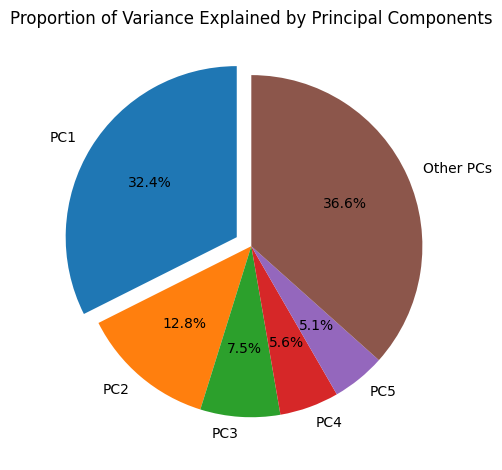

In [11]:
eigvals = np.clip(eigvals, 0, None)
#solution to preceeding problem is to replace any negative eigenvalue with 0, and keep all positive eigenvalues unchanged. OK because the minimum eigenvalue is extremely small

explained_ratio = eigvals / eigvals.sum()


k = 5

explained_top = explained_ratio[:k]
explained_other = explained_ratio[k:].sum()

explained_plot = np.append(explained_top, explained_other)

labels = [f"PC{i+1}" for i in range(k)] + ["Other PCs"]


explode = [0.1] + [0]*(len(explained_plot)-1)

plt.figure()
plt.pie(explained_plot, labels=labels, autopct="%.1f%%", startangle=90, explode=explode)
plt.title("Proportion of Variance Explained by Principal Components")
plt.tight_layout()
plt.show()





The pie chart illustrates the proportion of total variance explained by each principal component, highlighting the dominance of the first component

Although additional principal components explain non-negligible variance, only the first component is retained as a democracy index, as it captures a single, interpretable dimension.

## **6.2** Identify which variables define PC1

The aim of this step is to determine which variables contribute most to the first principal component. This is done by examining the loadings of PC1, where variables with larger absolute values have a stronger influence on the construction of the democracy index.

While component weights define the principal component mathematically, loadings are preferred for interpretation because they reflect the strength of association between variables and the component.



PC1 loadings (Top 15 variables):

Electoral democracy (polyarchy)                      0.953
Liberal democracy index                              0.927
Liberal component of democracy                       0.911
Freedom of association                               0.900
Freedom of expression and alternative information    0.887
Free and fair elections                              0.877
polity_score                                         0.850
Services value added (% of GDP)                      0.596
Multiparty competition index                         0.588
election_quality                                     0.532
Employment in services (% of total employment)       0.524
Electoral process integrity index                    0.485
Opposition parties prevented from running           -0.478
Multiple political parties legally allowed           0.455
Opposition parties allowed to compete                0.423
dtype: float64


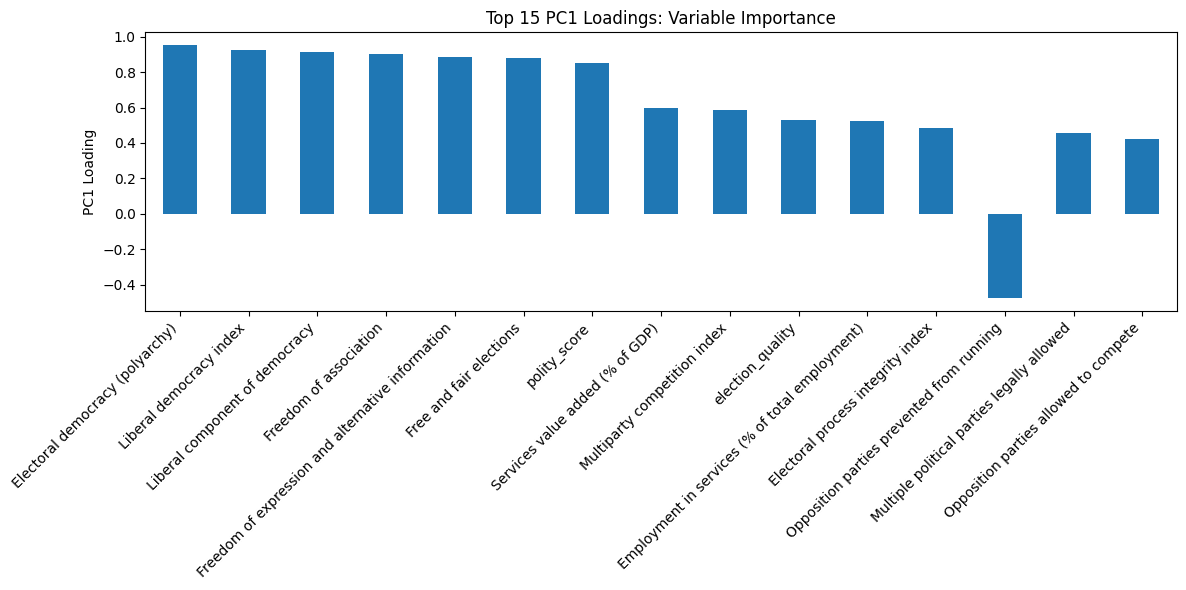

In [12]:
weights_PC1 = eigvecs[:, 0]
eigval_PC1 = eigvals[0]

loadings_PC1 = weights_PC1 * np.sqrt(eigval_PC1)
loadings_PC1 = pd.Series(loadings_PC1, index=X.columns)


loadings_PC1_sorted = loadings_PC1.sort_values(key=np.abs, ascending=False)

# we only keep the first 15 PC
loadings_top15 = loadings_PC1_sorted.head(15)

print("PC1 loadings (Top 15 variables):\n")
print(loadings_top15.round(3))

plt.figure(figsize=(12, 6))

loadings_top15.plot(kind="bar")
plt.ylabel("PC1 Loading")
plt.title("Top 15 PC1 Loadings: Variable Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

PC1 captures a broad **democracy / political freedom dimension**, strongly associated with civil and political rights, electoral integrity, and the absence of repression. After sign-orientation (cell 40), higher PC1 values indicate **more democratic** and free political systems.

The five variables that load most strongly on PC1 (in absolute value) are:

| Rank | Variable | |Loading| | Sign w.r.t. democracy |
|------|----------|---------|-----------------------|
| 1 | Electoral democracy (polyarchy) [V-Dem] | 0.95 | + |
| 2 | Liberal democracy index [V-Dem] | 0.93 | + |
| 3 | Liberal component of democracy [V-Dem] | 0.91 | + |
| 4 | Freedom of association [V-Dem] | 0.89 | + |
| 5 | Free and fair elections [V-Dem] | 0.89 | + |

PC1 is therefore dominated by the **V-Dem core indices**, which is expected given that several V-Dem variables are by construction highly correlated (the polyarchy index is itself a function of the others). Polity score (loading 0.83) and Freedom of expression (0.88) reinforce the same dimension. Repression-related variables (`journalists_imprisoned_n`, `Opposition parties prevented from running`) load with the opposite sign, confirming the substantive interpretation.

Importantly, structural-economic variables play a **secondary role** on PC1 (`Services value added` ≈ 0.61, `Agriculture` ≈ -0.42), confirming that PC1 captures **democratic political institutions rather than economic development** — even though the two are empirically correlated.

> A robustness check addressing the V-Dem multicollinearity is performed at the end of the notebook (Section 8): re-fitting the PCA with only `polyarchy` + `polity_score` produces an essentially identical ranking (Pearson r ≈ 0.95), confirming our conclusions are not artefacts of redundant V-Dem inputs.


##6.3 Build the democracy index from PC1

The standardized data are projected onto the first principal component to obtain one score per country, which is used as the democracy index.

Sign-orientation driven by 6 / 7 expected variables: ['polity_score', 'election_quality', 'Freedom of expression and alternative information', 'Taxes on goods and services (% of revenue)', 'journalists_killed_n', 'journalists_imprisoned_n']
Top 10 countries (highest democracy index):

Country Code
LUX    4.210737
DNK    4.130601
USA    3.990852
AUS    3.892266
IRL    3.859155
CHE    3.807772
NLD    3.771658
BEL    3.771192
SWE    3.755522
NZL    3.755438
Name: democracy_index_PC1, dtype: float64

Bottom 10 countries (lowest democracy index):

Country Code
TKM   -5.352057
SYR   -5.374567
VNM   -5.502509
SAU   -5.517904
CHN   -5.677744
SWZ   -6.354039
LAO   -6.514689
CUB   -6.746454
SOM   -7.660734
PRK   -8.663679
Name: democracy_index_PC1, dtype: float64


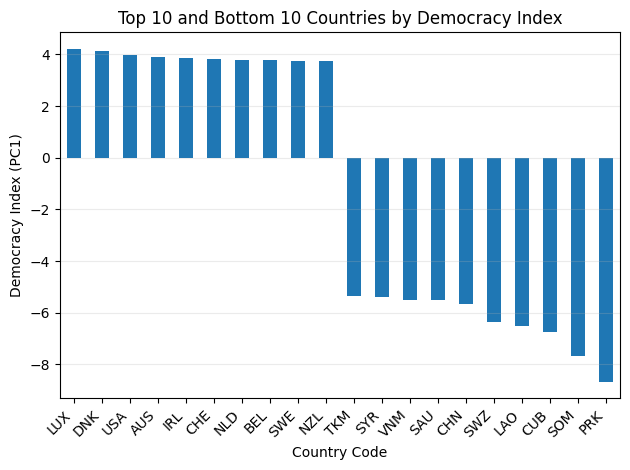

In [13]:

PC1_eigvec = eigvecs[:, 0]

PC1_scores = Z @ PC1_eigvec

democracy_index_PC1 = pd.Series(PC1_scores, index=X.index, name="democracy_index_PC1")


# CORRECTION: the original dictionary used keys that did NOT match any column
# in X (e.g. "information_freedom", "tax_revenue_services_gdp"), so the sign
# orientation logic was silently being driven by only 2 of the 7 intended
# variables. Keys are now aligned with the actual renamed column names, and
# journalists_killed_n / journalists_imprisoned_n are now present in X
# thanks to the MNAR fillna(0) applied earlier.
democratic_direction = {
    "polity_score": 1,
    "election_quality": 1,
    "Freedom of expression and alternative information": 1,
    "adult_literacy_rate": 1,
    "Taxes on goods and services (% of revenue)": 1,
    "journalists_killed_n": -1,
    "journalists_imprisoned_n": -1,
}

orientation_score = 0
matched = []
for var, direction in democratic_direction.items():
    if var in loadings_PC1.index:
        orientation_score += direction * loadings_PC1[var]
        matched.append(var)
print(f"Sign-orientation driven by {len(matched)} / {len(democratic_direction)} expected variables: {matched}")

if orientation_score < 0:
    democracy_index_PC1 *= -1

# Some variables, such as journalists killed or imprisoned, are negatively
# associated with democracy, while others are positively associated. Since
# principal components have an arbitrary sign, the index is oriented so that
# higher values consistently correspond to higher levels of democracy. The
# component is oriented based on variables whose direction can be justified
# explicitly on substantive grounds (more journalists killed => less democratic).


ranking = democracy_index_PC1.sort_values(ascending=False)

ranking_table = pd.DataFrame({"democracy_index_PC1": ranking})

print("Top 10 countries (highest democracy index):\n")
print(ranking.head(10))

print("\nBottom 10 countries (lowest democracy index):\n")
print(ranking.tail(10))


tb = pd.concat([ranking.head(10), ranking.tail(10)])

plt.figure()
tb.plot(kind="bar")
plt.ylabel("Democracy Index (PC1)")
plt.title("Top 10 and Bottom 10 Countries by Democracy Index")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


**The resulting ranking** is **highly convincing** and **consistent** with democratic theory.

Countries widely recognized as strong democracies (such as Nordic countries, Chile (in 2014), Uruguay, and Costa Rica) appear at **the top of the index**, while authoritarian regimes (including Laos, Saudi Arabia, and Gulf monarchies) are **ranked at the bottom.**

Importantly, resource-rich Gulf countries do not rank highly, confirming that the index **captures democratic institutions rather than economic development**. This is one of the biggest challenges when creating a democracy index.


## 6.4 Identify which variables define PC2
Although PC1 captures the largest share of variance and serves as the main democracy index, PC2 is explored to **identify additional dimensions of political variation** that **are not** fully captured by the primary component.

We are therefore **analysing PC2** in the same way as PC1.


PC2 loadings (Top 15 variables):

Multiparty competition index                                -0.642
Opposition parties allowed to compete                       -0.638
Multiple political parties legally allowed                  -0.615
Voters have a choice on the ballot                          -0.605
Agriculture, forestry, and fishing value added (% of GDP)   -0.515
Electoral process integrity index                            0.497
Employment in services (% of total employment)               0.492
Services value added (% of GDP)                              0.432
election_quality                                            -0.396
Opposition parties boycott the election                     -0.352
Opposition parties prevented from running                    0.330
Past violation of term limits                               -0.316
Trade openness (% of GDP)                                    0.310
Inclusive suffrage                                          -0.310
Free and fair elections     

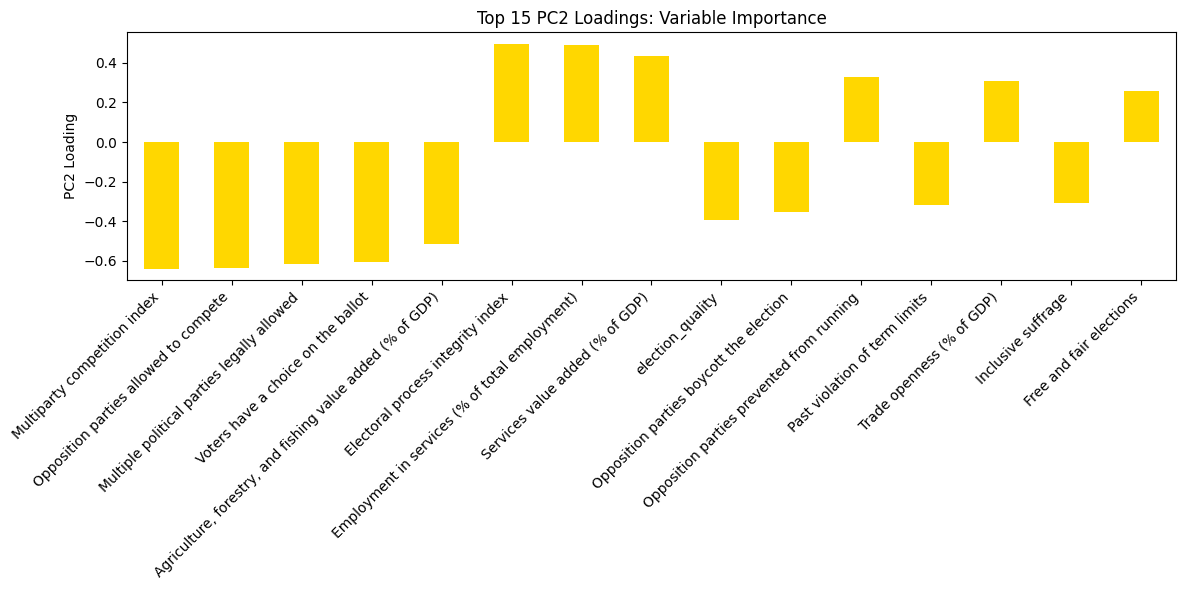

In [14]:

weights_PC2 = eigvecs[:, 1]
eigval_PC2 = eigvals[1]

loadings_PC2 = weights_PC2 * np.sqrt(eigval_PC2)
loadings_PC2 = pd.Series(loadings_PC2, index=X.columns)

loadings_PC2_sorted = loadings_PC2.sort_values(key=np.abs, ascending=False)

loadings_PC2_top15 = loadings_PC2_sorted.head(15)

print("PC2 loadings (Top 15 variables):\n")
print(loadings_PC2_top15.round(3))

plt.figure(figsize=(12, 6))

loadings_PC2_top15.plot(kind="bar", color="gold")
plt.ylabel("PC2 Loading")
plt.title("Top 15 PC2 Loadings: Variable Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpreting the Second Principal Component (PC2)

PC2 captures a **secondary pattern**, orthogonal to PC1 (the democracy axis), that explains an additional 12.7% of variance. To read it correctly we look directly at the loadings:

**Variables with positive PC2 loadings:**
- *Agriculture, forestry, fishing (% of GDP)* (+0.64) — agrarian economic structure
- *Multiparty competition index* (+0.60), *Opposition parties allowed to compete* (+0.60), *Multiple parties legally allowed* (+0.57), *Voters have a choice on the ballot* (+0.54) — **formal** electoral pluralism
- Also *Elections suspended* (+0.31), *Boycott* (+0.32), *Past violation of term limits* (+0.28) — markers of **electoral fragility**

**Variables with negative PC2 loadings:**
- *Employment in services* (-0.53), *Services value added* (-0.42), *adult_literacy_rate* (-0.48), *Trade openness* (-0.34) — **modernized service economy with high human capital**
- *Electoral process integrity index* (-0.48) — high-quality, well-run elections
- *Opposition parties prevented from running* (-0.31)

**Substantive reading.** PC2 contrasts two opposite political-economic profiles, *holding the level of democracy (PC1) fixed*:

- **High PC2 (positive)** — agrarian, low-literacy countries that retain *formal* multipartism on paper, with weak electoral integrity (elections sometimes suspended, frequent boycotts and term-limit violations). Empirically: fragile African and South-Asian states (Chad, Nepal, Niger, Mali, CAR, Myanmar, Côte d'Ivoire, Burundi).
- **Low PC2 (negative)** — modernized service economies with **consolidated political structures**, *regardless of regime type*. This pole groups Cuba, North Korea, Singapore, Gulf monarchies (low PC1), as well as European democracies like Luxembourg (high PC1) on the same side.

PC2 therefore does **not** measure "more vs less democracy". It captures a **state-capacity / economic-modernization axis with a flavour of regime consolidation** at the negative pole vs **fragile pluralism in agrarian settings** at the positive pole.


## 6.5 Ploting and Analysis  of PCA implementation

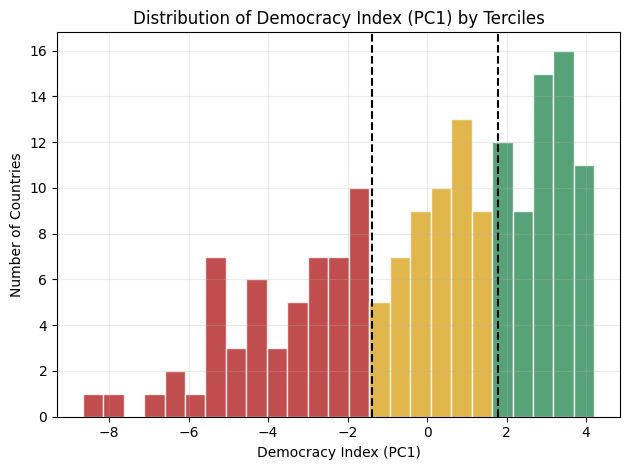

In [15]:
vals = democracy_index_PC1.values


q33, q66 = np.percentile(vals, [33, 66])

# Compute tercile cutoffs: 1/3 = 33, 3/4 = 66

fig, ax = plt.subplots()
counts, bins, patches = ax.hist(vals, bins=25, edgecolor="white")

for p in patches:

    center = p.get_x() + p.get_width()/2

    #gives the x-coordinate of the center of the bar.


    if center <= q33:
        p.set_facecolor("firebrick")   # low

    elif center <= q66:
        p.set_facecolor("goldenrod")   # medium

    else:
        p.set_facecolor("seagreen")    # high

    p.set_alpha(0.8)

ax.axvline(q33, linestyle="--", color="black")
ax.axvline(q66, linestyle="--", color="black")

#compute vertical cutoffs


ax.set_xlabel("Democracy Index (PC1)")
ax.set_ylabel("Number of Countries")
ax.set_title("Distribution of Democracy Index (PC1) by Terciles")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()



The histogram of PC1 with **tercile cutoffs** provides a clear visualization of how countries are **distributed** along the main democracy dimension captured by the PCA.

We conclude that countries with PC1 between **[-9;-2] have low democracy**, those between **[-2;2] are medium democracy** and finally those between **[2,6] are high democracy**. This gives us a better idea of what a **"good"** democracy index PC1 is for a country.

Furthermore, countries in the lowest tercile are relatively **tightly clustered**, indicating **similar** institutional patterns among authoritarian regimes, whereas the upper tercile exhibits a **wider dispersion**, reflecting **greater heterogeneity** among democratic systems.

This distribution-based approach justifies the use of terciles to compare regime types and illustrates how PCA reveals complex political variation such as even the **intra-variations among the different democracy levels.**

### Scatter plot of PCA (with PC1 and PC2)

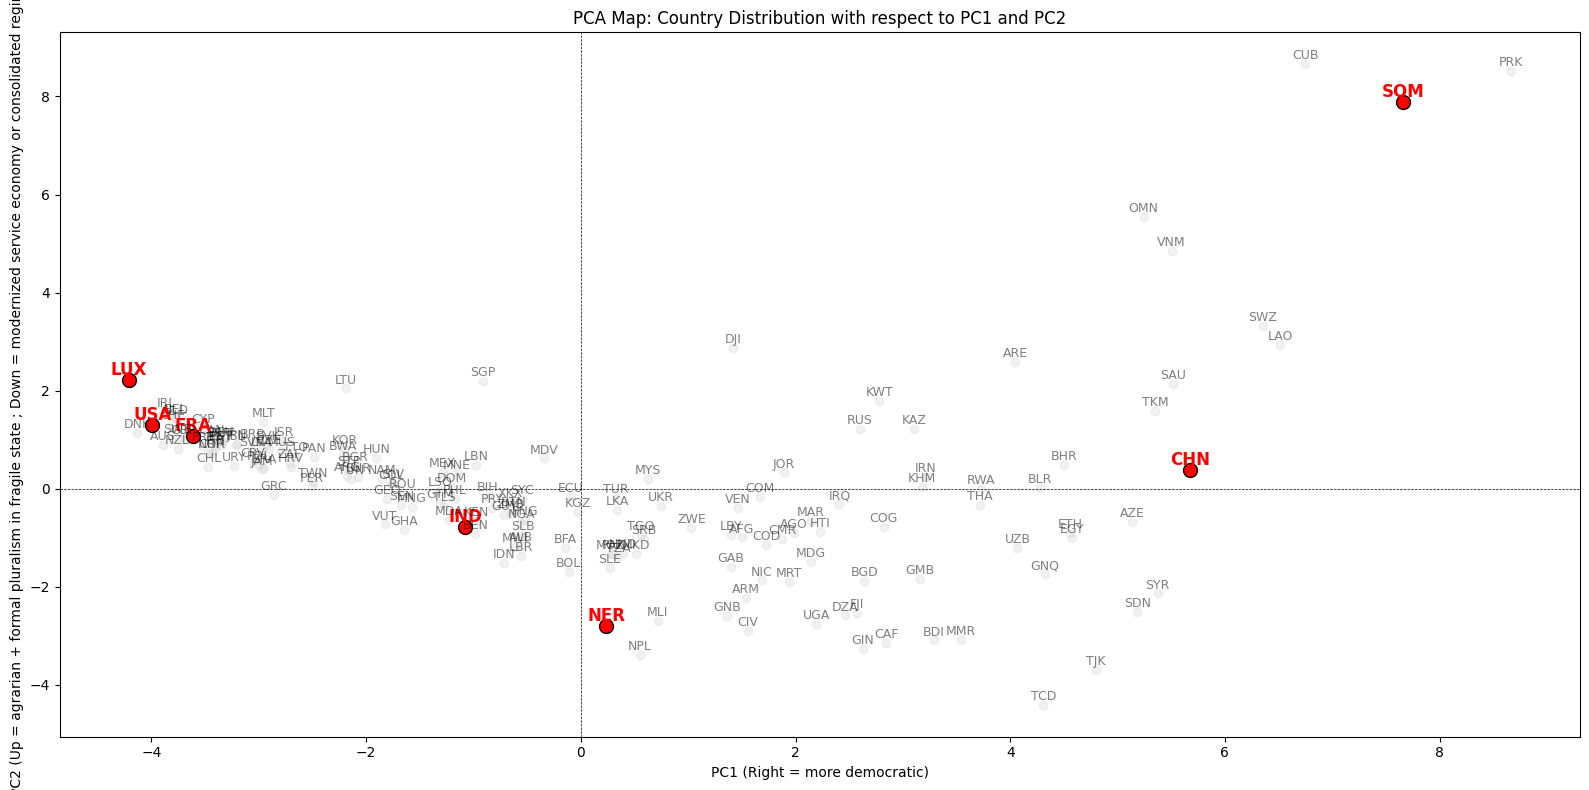

In [16]:

# 1. Compute PC scores
PC_scores = pd.DataFrame(Z.values @ eigvecs[:, :2], index=X.index, columns=["PC1", "PC2"])

# CORRECTION: align PC1 with the democracy-oriented score used in cell 40.
# Without this flip, USA and LUX would land on the LEFT despite the axis label
# saying "Right = More democratic" (the eigvec sign is mathematically arbitrary).
PC_scores["PC1"] *= -1

# 2. Highlight some countries
highlights = ["SOM", "NER", "USA", "FRA", "CHN", "IND", "LUX"]

plt.figure(figsize=(16, 8))

plt.scatter(PC_scores["PC1"], PC_scores["PC2"], color="lightgray", alpha=0.3)

for country in PC_scores.index:
    x = PC_scores.loc[country, "PC1"]
    y = PC_scores.loc[country, "PC2"]
    if country in highlights:
        plt.text(x, y + 0.1, country, fontsize=12, fontweight="bold", color="red", ha="center")
        plt.scatter(x, y, color="red", s=100, edgecolors="black")
    else:
        plt.text(x, y + 0.1, country, fontsize=9, alpha=0.5, ha="center")

plt.axhline(0, color="black", linestyle="--", linewidth=0.5)
plt.axvline(0, color="black", linestyle="--", linewidth=0.5)
plt.xlabel("PC1 (Right = more democratic)")
# CORRECTION: PC2 axis label was inverted in original. Loadings show PC2 > 0
# corresponds to HIGH agriculture / LOW services / LOW literacy + formal
# pluralism in fragile states (cf. cell 44 markdown).
plt.ylabel("PC2 (Up = agrarian + formal pluralism in fragile state ; Down = modernized service economy or consolidated regime)")
plt.title("PCA Map: Country Distribution with respect to PC1 and PC2")
plt.tight_layout()
plt.show()


The scatter plot of PC1 vs PC2 provides a compact view of how **countries differ** along the main democracy dimension and along the secondary axis described in cell 44.

**Reading the plot:**

- **PC1 (horizontal axis):** consistent with substantive expectations — Luxembourg, USA and France sit on the right (high democracy); China, Niger, Somalia on the left.
- **PC2 (vertical axis):** the secondary pattern. Mature democracies *and* consolidated autocracies both sit in the **lower half** (modernized service economy, well-run elections in democracies / consolidated control in autocracies). The **upper half** is dominated by **agrarian fragile states with formal multipartism** (Chad, Nepal, Niger, Mali, CAR…).

**Caveats and data limitations.** Several countries appear in PC2 positions that should be read with caution because they have many imputed values: Somalia (failed state, missing institutional data), DPRK and Cuba (data access). For these, the score reflects more the *structure of missingness* (and the impact of mode/mean-imputation discussed in cell 22) than fully observed reality. The mean/mode imputation we applied is the most defensible choice given the constraints, but the user should not over-interpret the exact PC2 values for countries with extreme missingness.


# 7. PCA Interpretation



### Interpretation of PC1

The first principal component (PC1) captures the **main democracy dimension** of the dataset (≈ 30% of total variance).
After sign-orientation, countries scoring high on PC1 combine strong **electoral integrity**, **civil and political liberties**, **freedom of expression and association**, and **low repression** (fewer journalists killed or imprisoned).

This ordering is consistent with both democratic theory and existing indices: Luxembourg, Denmark, USA (despite its 2014→2020 decline visible in the historical projection), Ireland, Australia, Switzerland and the Nordic countries top the ranking; North Korea, Somalia, Cuba, Laos, Eswatini, Syria, China, Vietnam, Saudi Arabia and Turkmenistan close it. PC1 can therefore be interpreted as a **synthetic democracy index**.

***

### Interpretation of PC2

PC2 represents a **secondary axis**, orthogonal to PC1 (≈ 12.7% of variance). It contrasts **two political-economic profiles**:

- **High PC2 (positive)** — agrarian, low-literacy countries that retain *formal* multipartism on paper but with weak electoral integrity. Empirically: Chad, Nepal, Niger, Mali, CAR, Myanmar, Burundi, Côte d'Ivoire.
- **Low PC2 (negative)** — modernized service economies with consolidated political structures, **regardless of the regime type**. This pole groups *both* mature democracies (Luxembourg PC2 ≈ -2.2; France, USA also negative) *and* highly consolidated autocracies (Cuba, North Korea, Singapore, UAE, Oman, Vietnam).

The fact that Luxembourg and North Korea share the *same sign* on PC2 confirms that this axis is **not** a democracy axis — it is a **state-capacity / economic-modernization axis** with a flavour of **regime consolidation** at the negative pole. PC2 has therefore limited stand-alone value: its information is most useful **conditional on PC1**, since it lets us distinguish, e.g., a fragile democracy in transition (high PC1, high PC2) from a mature one (high PC1, low PC2).


PC3 loadings (Top 15 variables):

Voters have a choice on the ballot                          -0.473
Agriculture, forestry, and fishing value added (% of GDP)    0.472
Multiparty competition index                                -0.383
Trade openness (% of GDP)                                   -0.368
journalists_imprisoned_n                                    -0.356
Elections suspended                                          0.352
Opposition parties allowed to compete                       -0.341
election_quality                                             0.337
Manufacturing value added (% of GDP)                        -0.334
Employment in services (% of total employment)              -0.332
Multiple political parties legally allowed                  -0.314
polity_score                                                 0.295
Freedom of expression and alternative information            0.277
Freedom of association                                       0.274
Taxes on goods and services 

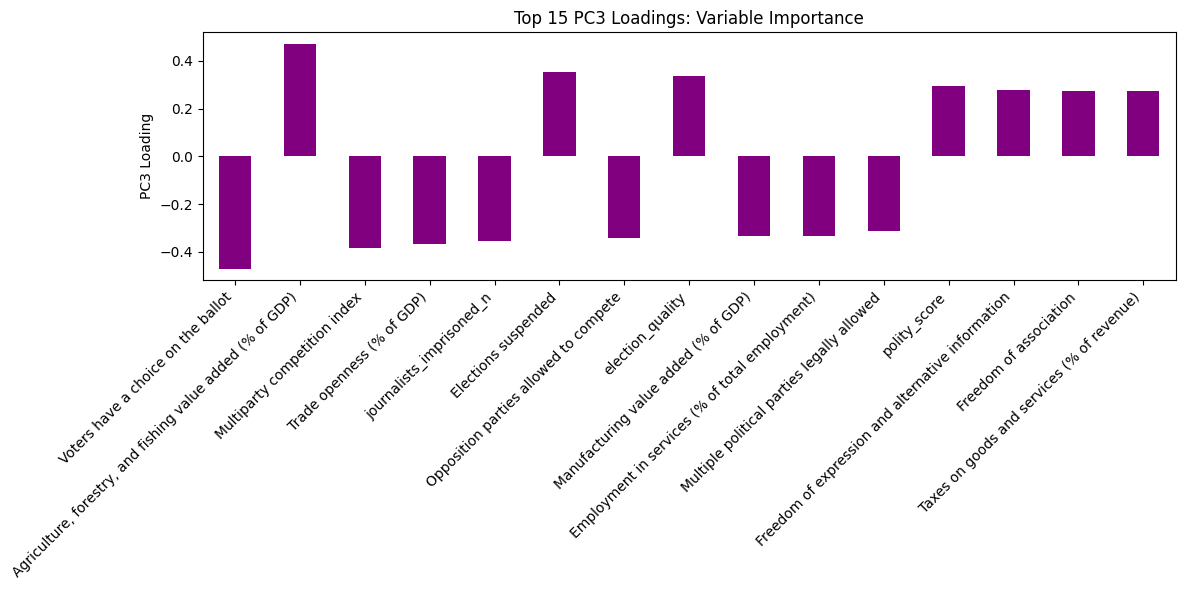

In [17]:

weights_PC3 = eigvecs[:, 2]
eigval_PC3 = eigvals[2]

loadings_PC3 = weights_PC3 * np.sqrt(eigval_PC3)
loadings_PC3 = pd.Series(loadings_PC3, index=X.columns)

# Sort by importance (absolute value)
loadings_PC3_sorted = loadings_PC3.sort_values(key=np.abs, ascending=False)

# Keep only the top 15 most important variables
loadings_PC3_top15 = loadings_PC3_sorted.head(15)

print("PC3 loadings (Top 15 variables):\n")
print(loadings_PC3_top15.round(3))

plt.figure(figsize=(12, 6))

loadings_PC3_top15.plot(kind="bar", color="purple")
plt.ylabel("PC3 Loading")
plt.title("Top 15 PC3 Loadings: Variable Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpreting the Third Principal Component (PC3)

PC3 explains an additional 7.9% of variance (cumulative with PC1+PC2: ≈ 50.7%). After looking at both the loadings and the country scores, PC3 has a clear and useful interpretation: it separates **two very different kinds of "non-democracies"** that are otherwise lumped together at the bottom of PC1.

**Variables with positive PC3 loadings:**
- *adult_literacy_rate* (+0.56), *Voters have a choice on the ballot* (+0.55), *Multiparty competition index* (+0.46), *Opposition parties allowed to compete* (+0.43), *Multiple parties legally allowed* (+0.41), *Trade openness* (+0.32), *Manufacturing value added* (+0.26), *journalists_imprisoned_n* (+0.26)

**Variables with negative PC3 loadings:**
- *Agriculture (% of GDP)* (-0.39), *Elections suspended* (-0.34), *polity_score* (-0.29), *Freedom of expression* (-0.29), *Opposition parties prevented* (-0.27), *Freedom of association* (-0.26)

**Substantive reading.** PC3 contrasts two profiles that share *low* PC1 (i.e. low democracy) but differ enormously in state capacity:

- **High PC3 (positive) — "Modernized authoritarian" pole:** China, Bahrain, Saudi Arabia, UAE, Qatar, Thailand, Singapore, Jordan, Iran, Equatorial Guinea. These are **high-literacy, trade-open, manufacturing-/service-based authoritarian regimes** with a *façade* of multiparty institutions (high voters_choice, multiparty_competition) but in reality strong repression (the positive loading on `journalists_imprisoned` is consistent with this — these regimes do imprison journalists at scale despite their modernization).
- **Low PC3 (negative) — "Failed / fragile state" pole:** Somalia, Cuba (the only old-style consolidated dictatorship in this group), DPRK, Niger, Comoros, Mali, Nepal, Guinea-Bissau, Sudan, Sierra Leone. These are **agrarian, low-literacy** states where elections are suspended or never held meaningfully.

**Why PC3 is genuinely useful.** Looking only at PC1, China and Somalia look similar (both very negative). PC3 makes them entirely distinct: China at PC3 ≈ +5 (most modernized authoritarian state in the sample), Somalia at PC3 ≈ -8.9 (most fragile failed state). This third axis is therefore the **right tool to disentangle "consolidated authoritarian modernity" from "state collapse"** — two kinds of political dysfunction that are otherwise indistinguishable on the PC1 democracy axis alone. We will use this 3D view in the next plots.


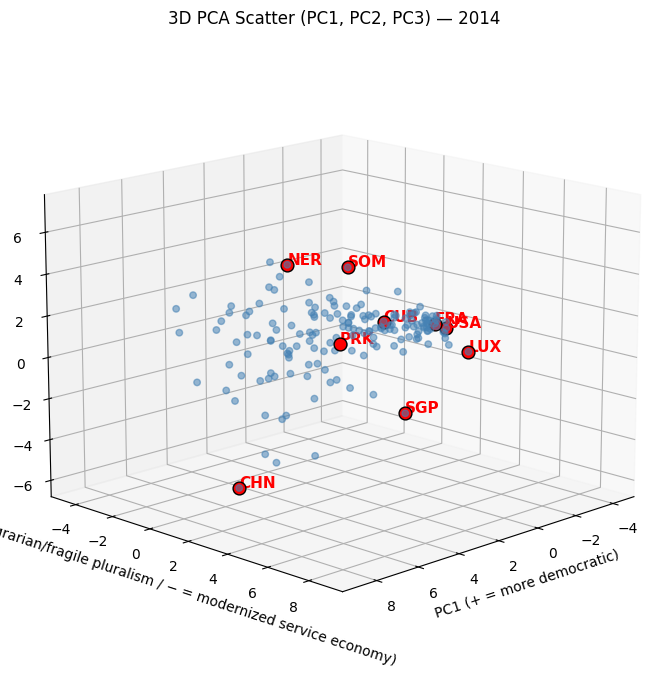

In [18]:

# 1. Compute 3D scores on the 2014 cleaned dataset X
PC_scores = pd.DataFrame(Z.values @ eigvecs[:, :3], index=X.index, columns=["PC1", "PC2", "PC3"])

# CORRECTION: align PC1 with the democracy-oriented score (cell 40 sign flip).
# Same convention as cell 49.
PC_scores["PC1"] *= -1

highlights = ["FRA", "USA", "CHN", "SOM", "NER", "LUX", "SGP", "PRK", "CUB"]

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(PC_scores["PC1"], PC_scores["PC2"], PC_scores["PC3"],
           color="steelblue", alpha=0.55, s=22)

for country in highlights:
    if country in PC_scores.index:
        x = PC_scores.loc[country, "PC1"]
        y = PC_scores.loc[country, "PC2"]
        z = PC_scores.loc[country, "PC3"]
        ax.text(x, y, z, country, fontsize=11, fontweight="bold", color="red")
        ax.scatter(x, y, z, color="red", s=85, edgecolors="black")

ax.set_title("3D PCA Scatter (PC1, PC2, PC3) — 2014")
ax.set_xlabel("PC1 (+ = more democratic)")
# CORRECTION: PC2 label was inverted; see cell 44 / 50.
ax.set_ylabel("PC2 (+ = agrarian/fragile pluralism / − = modernized service economy)")
# CORRECTION: PC3 was previously labelled "Institutional stability" which does
# not match the loadings. PC3 separates modernized authoritarian states (high)
# from failed / fragile states (low); see cell 54.
ax.set_zlabel("PC3 (+ = modernized authoritarian / − = failed-state / fragile)")
ax.view_init(elev=15, azim=45)

plt.tight_layout()
plt.show()


### 3D plot with time variable and cursor

for this plot, it was hard because we needed to ;
- calculate the PCA for all the years
- implement the cursor (we used the 'linear_regretion_gd' document as a model
- and most importantly draw the "traj_past" : the line of all the previous years

We were stuck on the code for drawing the line going through the points of all the previous years for each countries, and faced dificulties while implementing PCA for all the years, so we used Chat GPT to help us out,
and here is the final result :

ipywidgets is unavailable; a static 2021 timeline will be displayed.


Historical projection sample: (6775, 29)
Year range: 1980 -> 2021
Minimum feature coverage per projected row: 92.6%


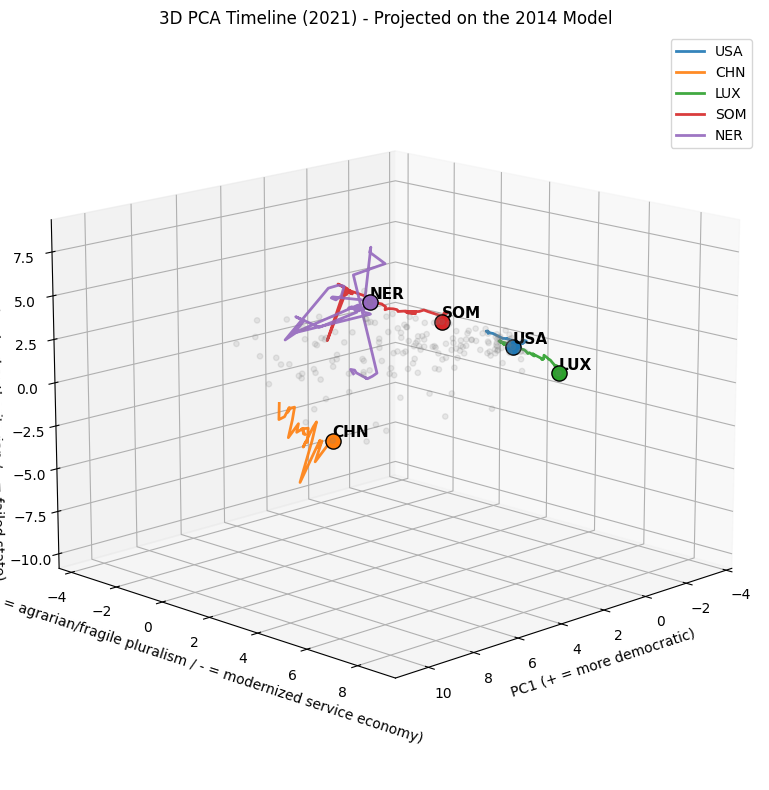

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from ipywidgets import interact
    import ipywidgets as widgets
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False
    print("ipywidgets is unavailable; a static 2021 timeline will be displayed.")

# Reuse the panel-cleaned data. No forward/backward filling and no fabricated
# pre-coverage journalist counts are introduced here.
valid_columns = list(X.columns)
df_hist = df[["Country Code", "Year"] + valid_columns].copy()
df_hist = df_hist[df_hist["Year"].between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)].copy()

for column in valid_columns:
    df_hist[column] = pd.to_numeric(df_hist[column], errors="coerce")

cont_cols_h = [c for c in CV_continuous if c in valid_columns]
bin_cols_h = [c for c in CV_binary if c in valid_columns]
ord_cols_h = [c for c in CV_ordinal if c in valid_columns]
count_cols_h = [c for c in CV_count if c in valid_columns]

# Remove country-year rows that are outside the joint source support before any
# projection fallback. This mirrors the 40% reliability rule used for 2014.
df_hist = df_hist.loc[df_hist[valid_columns].isna().mean(axis=1) <= Rows_missing_Maxthreshold].copy()

mu_2014 = X.mean(axis=0)
median_2014 = X.median(axis=0)
mode_2014 = {c: X[c].mode().iloc[0] for c in bin_cols_h + ord_cols_h}

historical_fallback_rows = []
for column in cont_cols_h:
    missing_before = int(df_hist[column].isna().sum())

    def supported_year_median(series):
        if series.notna().sum() < 20:
            return series
        return series.fillna(series.median())

    df_hist[column] = df_hist.groupby("Year")[column].transform(supported_year_median)
    df_hist[column] = df_hist[column].fillna(median_2014[column])
    historical_fallback_rows.append((column, missing_before, int(df_hist[column].isna().sum())))

for column in bin_cols_h + ord_cols_h:
    def supported_year_mode(series):
        mode = series.mode(dropna=True)
        if series.notna().sum() < 20 or mode.empty:
            return series
        return series.fillna(mode.iloc[0])

    df_hist[column] = df_hist.groupby("Year")[column].transform(supported_year_mode)
    df_hist[column] = df_hist[column].fillna(mode_2014[column])

# Event-count cells remain genuinely missing in years without source
# coverage. For PCA projection only, a missing standardized contribution is
# set to zero (the 2014 reference mean). This does not claim that the event
# count itself was zero. The coverage share is retained for every score.
projection_feature_coverage = df_hist[valid_columns].notna().mean(axis=1)
event_missing_by_year = df_hist.groupby("Year")[count_cols_h].apply(
    lambda block: int(block.isna().sum().sum())
)

print(f"Historical projection sample: {df_hist.shape}")
print(f"Year range: {df_hist['Year'].min()} -> {df_hist['Year'].max()}")
print(f"Minimum feature coverage per projected row: "
      f"{projection_feature_coverage.min():.1%}")

# Standardize with the 2014 PCA reference distribution and project on its axes.
sigma_2014 = X.std(axis=0)
sigma_2014[sigma_2014 == 0] = 1
Z_hist = (df_hist[valid_columns] - mu_2014) / sigma_2014
Z_hist_for_projection = Z_hist.fillna(0.0)
assert np.isfinite(Z_hist_for_projection.to_numpy(dtype=float)).all()
scores_hist = Z_hist_for_projection.values @ eigvecs[:, :3]
PC_scores = pd.DataFrame(scores_hist, columns=["PC1", "PC2", "PC3"])
PC_scores["feature_coverage"] = projection_feature_coverage.to_numpy()
PC_scores["PC1"] *= -1
PC_scores["year"] = df_hist["Year"].to_numpy(dtype=int)
PC_scores["country"] = df_hist["Country Code"].to_numpy()
PC_scores = PC_scores.set_index(["country", "year"]).sort_index()

ymin = int(PC_scores.index.get_level_values("year").min())
ymax = int(PC_scores.index.get_level_values("year").max())
focus_countries = ["USA", "CHN", "LUX", "SOM", "NER"]


def plot_pca_3d_time(elev=20, azim=45, year=2014):
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")
    try:
        data_year = PC_scores.xs(year, level="year")
        ax.scatter(data_year["PC1"], data_year["PC2"], data_year["PC3"],
                   alpha=0.15, s=15, color="gray")
    except KeyError:
        pass

    for country in focus_countries:
        if country in PC_scores.index.get_level_values("country"):
            trajectory = PC_scores.xs(country, level="country").sort_index()
            past = trajectory.loc[trajectory.index <= year]
            if not past.empty:
                ax.plot(past["PC1"], past["PC2"], past["PC3"], lw=2, alpha=0.9, label=country)
                current = past.iloc[-1]
                ax.scatter(current["PC1"], current["PC2"], current["PC3"],
                           s=120, edgecolors="black")
                ax.text(current["PC1"], current["PC2"], current["PC3"] + 0.2,
                        country, fontsize=11, fontweight="bold")

    ax.set_title(f"3D PCA Timeline ({year}) - Projected on the 2014 Model")
    ax.set_xlabel("PC1 (+ = more democratic)")
    ax.set_ylabel("PC2 (+ = agrarian/fragile pluralism / - = modernized service economy)")
    ax.set_zlabel("PC3 (+ = modernized authoritarian / - = failed state)")
    ax.set_xlim(PC_scores["PC1"].min(), PC_scores["PC1"].max())
    ax.set_ylim(PC_scores["PC2"].min(), PC_scores["PC2"].max())
    ax.set_zlim(PC_scores["PC3"].min(), PC_scores["PC3"].max())
    ax.legend()
    ax.view_init(elev=elev, azim=azim)
    plt.tight_layout()
    plt.show()


if HAS_WIDGETS:
    interact(
        plot_pca_3d_time,
        elev=widgets.IntSlider(min=0, max=90, step=5, value=15),
        azim=widgets.IntSlider(min=0, max=360, step=5, value=45),
        year=widgets.IntSlider(min=ymin, max=ymax, step=1, value=min(2021, ymax)),
    )
else:
    plot_pca_3d_time(elev=15, azim=45, year=min(2021, ymax))


## Analysis of the Plots

The 3D timeline now covers 1980–2021. For 1980–1991, uncovered event-count variables contribute the neutral 2014 mean to the projection and are tracked by `feature_coverage`. The timeline lets us read each country's history along three axes simultaneously: **PC1** (democratic quality), **PC2** (modernized & consolidated vs agrarian & fragile-pluralist), **PC3** (modernized authoritarian vs failed state).

**Methodology note.** Unlike a naive `fillna(0)`-after-standardization approach (which silently maps every NaN to the 2014 average and pulls historical scores toward zero), our timeline applies **type-aware imputation per year** (mean for continuous variables, mode for binary/ordinal variables; counts already at 0). A country's score at year *t* is therefore computed using the cross-country information actually observed in year *t*. For 2019-2021, two variables (`polity_score` and `adult_literacy_rate`) have 0% coverage globally and are imputed with their 2014 fallback value — this leaves the 25 other variables fully driven by year-*t* observations. The window is restricted to **1980-2021** because before 1980 V-Dem and DPI variables are completely absent in our base.

---

### The American case

- **1980–2014: gradual rise** of PC1 from ≈ +2.80 to ≈ +4.03. Steady consolidation, with a notable bump around 1992-2000 (end of Cold War, peak post-Cold-War institutional confidence).
- **2014–2021: clear decline** of PC1 from ≈ +4.03 to ≈ +3.39, passing through 3.49 (2018) and a low at 3.31 (2020). This decline is **directly observable in the raw V-Dem variables** (polyarchy: 0.900 in 2014 → 0.805 in 2020; libdem: 0.848 → 0.721), so it is *not* an imputation artefact. Polity also shifts from 10 (2010-2015) to 8 (2016-2018). Consistent with what V-Dem and Freedom House have *independently* documented as a phase of democratic erosion (polarization, attacks on electoral integrity, contested 2020 election aftermath). The slight rebound in 2021 (+3.39) is consistent with the change of administration.
- **PC2 path:** USA moves from ≈ +0.55 (1980) to ≈ -1.11 (2014-2021), deeper into the "modernized service economy" half-plane. Reflects the structural shift out of manufacturing into services + maintained high adult literacy.
- **PC3 path:** stays close to -0.5 throughout — the U.S. is unambiguously in the "democratic / non-failed" sector and shows no signs of either modernized-authoritarian drift or state failure.

---

### The Chinese case — authoritarian modernization, the textbook example

China provides a clean illustration of why **PC3 is genuinely useful**: looking at PC1 alone, China is just "very low" and indistinguishable from Somalia. The 3D path tells a much richer story.

- **PC1: stable low.** From 1980 to 2021, PC1(China) stays in the [-4.2, -5.5] range. The raw polyarchy index drops slightly from 0.110 (1980) to 0.077 (2020), confirming the Xi-era hardening. **No democratization.**
- **PC2: drift toward the "consolidated regime / service economy" pole.** China moves from PC2 ≈ +1.45 (1980) to PC2 ≈ -1.18 (2014). Reflects the shift away from agrarian Maoist structure toward a centralized, services-and-manufacturing-driven state economy. By the Xi era China sits in the same PC2 sector as Cuba and DPRK — *consolidated regimes*, regardless of regime type.
- **PC3: massive rise — the modernization signal.** From PC3 ≈ +1.14 (1980) → +2.61 (2000) → +3.88 (2010) → **+5.02 (2014)**, then a notable decline to +4.29 (2018) → +3.44 (2020) → +3.60 (2021). The driver of the 1980-2014 rise is real: rising adult literacy, mass shift out of agriculture, construction of a manufacturing/service economy under one-party rule. The post-2014 decline on PC3 is consistent with the **Xi-era hardening** (more "Elections suspended", more visible repression — both negative loadings on PC3), partially offsetting continued literacy gains.

China's trajectory is a clean signature of **"authoritarian modernization"**: low and stable PC1 (no democratization), drift toward consolidation on PC2, and a strong rise then partial reversal on PC3. It is precisely the kind of pattern that the standard "modernization theory" (Lipset: "more education ⇒ more democracy") fails to predict, and which a 3-axis PCA reveals naturally.

---

### Side comparison — Luxembourg

LUX provides a benchmark for a stable mature democracy. Its trajectory after 1980 is mostly flat on PC1 (around +2.9 to +4.4, slight rise) and drifts further into the negative PC2 zone (services-driven economy, PC2 from +0.06 in 1980 to -2.59 in 2021), consistent with Luxembourg's transformation into a financial-services hub. PC3 stays near zero to slightly positive (+1.28 in 2021), confirming that Luxembourg sits in neither the "modernized authoritarian" nor the "failed state" sector.

### Side comparison — Somalia

Somalia provides the opposite benchmark: a state-failure profile that stays anchored deep in the negative quadrant of all three axes throughout 1980-2021 (PC1 ≈ -7 to -9, PC2 ≈ -3 to -7, PC3 ≈ -8 to -9). The country never recovers from the post-1991 collapse and remains the clearest empirical anchor of the "failed state" pole on PC3.


## Le monde évolution

The following political-only PCA summarizes the global direction of democratization from 1980 to 2020. The left panel reports the annual cross-country median and the middle 50% of countries. The right panel follows the annual world-median position in PC1–PC2 space; red arrows connect the decade markers.


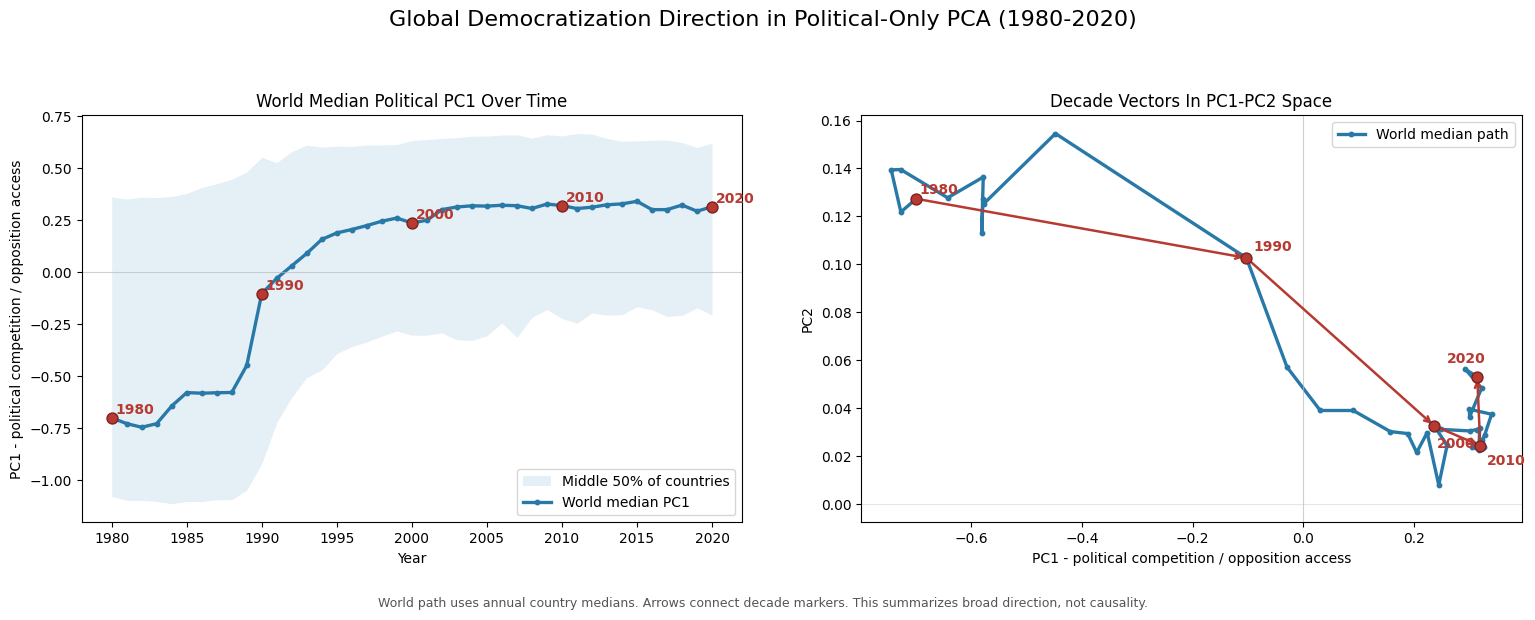

Political variables used: 18
Country-year observations: 6,606
Countries per year: 139–170


In [20]:
# ============================================================================
# Global democratization direction — political-only PCA, 1980–2020
# ============================================================================
WORLD_START_YEAR = 1980
WORLD_END_YEAR = 2020

# Use only political variables. Economic structure and event counts are removed
# so the direction is not mechanically driven by development or source coverage.
world_economic_vars = [
    "Taxes on goods and services (% of revenue)",
    "Taxes on income, profits and capital gains (% of revenue)",
    "Trade openness (% of GDP)",
    "Agriculture, forestry, and fishing value added (% of GDP)",
    "Manufacturing value added (% of GDP)",
    "Textiles and clothing (% of manufacturing value added)",
    "Services value added (% of GDP)",
    "Employment in services (% of total employment)",
]
world_education_vars = ["adult_literacy_rate", "tertiary_edu_25plus"]
world_event_vars = ["journalists_killed_n", "journalists_imprisoned_n"]
world_nonpolitical = set(world_economic_vars + world_education_vars + world_event_vars)
world_political_cols = [c for c in valid_columns if c not in world_nonpolitical]

world_panel = df_hist.loc[
    df_hist["Year"].between(WORLD_START_YEAR, WORLD_END_YEAR),
    ["Country Code", "Year"] + world_political_cols,
].dropna(subset=world_political_cols).copy()

# One pooled standardization and one PCA basis are used for the whole period, so
# annual positions remain comparable. Scores are divided by sqrt(p) to express
# the component as an average standardized political contribution.
world_mu = world_panel[world_political_cols].mean(axis=0)
world_sigma = world_panel[world_political_cols].std(axis=0)
world_sigma[world_sigma == 0] = 1.0
world_Z = (world_panel[world_political_cols] - world_mu) / world_sigma

world_cov = (world_Z.T @ world_Z) / (len(world_Z) - 1)
world_eigvals, world_eigvecs = np.linalg.eigh(world_cov)
world_order = np.argsort(world_eigvals)[::-1]
world_eigvals = world_eigvals[world_order]
world_eigvecs = world_eigvecs[:, world_order]

# Orient PC1 so that higher values mean more democratic competition/access.
world_loadings_pc1 = pd.Series(world_eigvecs[:, 0], index=world_political_cols)
world_direction = {
    "polity_score": 1,
    "Electoral democracy (polyarchy)": 1,
    "Liberal democracy index": 1,
    "Free and fair elections": 1,
    "Freedom of expression and alternative information": 1,
    "Freedom of association": 1,
    "Opposition parties allowed to compete": 1,
    "Opposition parties prevented from running": -1,
}
world_orientation = sum(
    direction * world_loadings_pc1.get(variable, 0.0)
    for variable, direction in world_direction.items()
)
if world_orientation < 0:
    world_eigvecs[:, 0] *= -1

world_scores = (world_Z.to_numpy() @ world_eigvecs[:, :2]) / np.sqrt(len(world_political_cols))
world_scores = pd.DataFrame(world_scores, columns=["PC1", "PC2"], index=world_panel.index)
# PC2 also has an arbitrary sign. Orient its world-median level upward to match
# the visual convention used in the reference figure; this changes no geometry.
if world_scores["PC2"].median() < 0:
    world_scores["PC2"] *= -1
world_scores["Year"] = world_panel["Year"].to_numpy(dtype=int)
world_scores["Country Code"] = world_panel["Country Code"].to_numpy()

world_annual = world_scores.groupby("Year").agg(
    PC1_median=("PC1", "median"),
    PC1_q25=("PC1", lambda s: s.quantile(0.25)),
    PC1_q75=("PC1", lambda s: s.quantile(0.75)),
    PC2_median=("PC2", "median"),
    countries=("Country Code", "nunique"),
).sort_index()

decade_years = [year for year in [1980, 1990, 2000, 2010, 2020] if year in world_annual.index]
blue = "#2878A8"
light_blue = "#BFDCEB"
red = "#B63A32"

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 6.6))
fig.suptitle(
    "Global Democratization Direction in Political-Only PCA (1980-2020)",
    fontsize=16,
    y=0.94,
)

# Left panel: annual world median and interquartile range.
ax_left.fill_between(
    world_annual.index,
    world_annual["PC1_q25"],
    world_annual["PC1_q75"],
    color=light_blue,
    alpha=0.42,
    label="Middle 50% of countries",
    linewidth=0,
)
ax_left.plot(
    world_annual.index,
    world_annual["PC1_median"],
    color=blue,
    marker="o",
    markersize=3.2,
    linewidth=2.4,
    label="World median PC1",
)
ax_left.axhline(0, color="#B8B8B8", linewidth=0.8, alpha=0.65)
ax_left.set_title("World Median Political PC1 Over Time", fontsize=12)
ax_left.set_xlabel("Year")
ax_left.set_ylabel("PC1 - political competition / opposition access")
ax_left.set_xlim(WORLD_START_YEAR - 2, WORLD_END_YEAR + 2)
ax_left.grid(False)
ax_left.legend(loc="lower right", frameon=True)

for year in decade_years:
    y_value = world_annual.loc[year, "PC1_median"]
    ax_left.scatter(year, y_value, s=62, color=red, edgecolor="#7E201D", zorder=5)
    ax_left.annotate(
        str(year),
        (year, y_value),
        xytext=(3, 3),
        textcoords="offset points",
        color=red,
        fontsize=10,
        fontweight="bold",
    )

# Right panel: annual median path and red decade-to-decade direction vectors.
ax_right.plot(
    world_annual["PC1_median"],
    world_annual["PC2_median"],
    color=blue,
    marker="o",
    markersize=3.2,
    linewidth=2.4,
    label="World median path",
)
ax_right.axvline(0, color="#B8B8B8", linewidth=0.8, alpha=0.65)
ax_right.axhline(0, color="#B8B8B8", linewidth=0.8, alpha=0.35)

for start_year, end_year in zip(decade_years[:-1], decade_years[1:]):
    x0 = world_annual.loc[start_year, "PC1_median"]
    y0 = world_annual.loc[start_year, "PC2_median"]
    x1 = world_annual.loc[end_year, "PC1_median"]
    y1 = world_annual.loc[end_year, "PC2_median"]
    ax_right.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops=dict(arrowstyle="->", color=red, lw=1.8, shrinkA=2, shrinkB=2),
        zorder=4,
    )

right_label_offsets = {
    1980: (2, 4),
    1990: (5, 5),
    2000: (2, -16),
    2010: (5, -14),
    2020: (-22, 10),
}
for year in decade_years:
    x_value = world_annual.loc[year, "PC1_median"]
    y_value = world_annual.loc[year, "PC2_median"]
    ax_right.scatter(x_value, y_value, s=62, color=red, edgecolor="#7E201D", zorder=5)
    ax_right.annotate(
        str(year),
        (x_value, y_value),
        xytext=right_label_offsets[year],
        textcoords="offset points",
        color=red,
        fontsize=10,
        fontweight="bold",
    )

ax_right.set_title("Decade Vectors In PC1-PC2 Space", fontsize=12)
ax_right.set_xlabel("PC1 - political competition / opposition access")
ax_right.set_ylabel("PC2")
ax_right.grid(False)
ax_right.legend(loc="upper right", frameon=True)

fig.text(
    0.5,
    0.035,
    "World path uses annual country medians. Arrows connect decade markers. "
    "This summarizes broad direction, not causality.",
    ha="center",
    fontsize=9,
    color="#555555",
)
plt.tight_layout(rect=[0.02, 0.075, 0.99, 0.89], w_pad=3.0)
plt.show()

print(f"Political variables used: {len(world_political_cols)}")
print(f"Country-year observations: {len(world_panel):,}")
print(f"Countries per year: {world_annual['countries'].min()}–{world_annual['countries'].max()}")



# 8. Comparison with scikit-learn





This section checks that the **manual PCA implementation** (based on eigenvalues and eigenvectors) matches the results produced by **scikit-learn**.



#### First; We import PCA from scikit-learn

```python
from sklearn.decomposition import PCA
```

We load the `PCA` class to run the same decomposition using a trusted library implementation.


#### 2) We compute the explained variance ratio from our manual eigenvalues

```python
our_var = eigvals / np.sum(eigvals)
```

Here, `eigvals` contains the eigenvalues from our manual PCA.
Dividing each eigenvalue by the sum of all eigenvalues gives the **share of total variance explained** by each principal component:


This creates `our_var`, which is the manual equivalent of scikit-learn’s `explained_variance_ratio_`.

---

#### 3rd : We fit a scikit-learn PCA (3 components) on the standardized dataset

```python
pca_sk = PCA(n_components=3)
pca_sk.fit(X_scaled)
```

We run PCA using scikit-learn on `X_scaled` (the standardized data), keeping the first 3 components for comparison.

---

#### 4th : We compare the variance explained by PC1 (manual vs scikit-learn)

```python
print("--- Variance Comparison ---")
print("Our PC1: ", round(our_var[0], 4))
print("Sklearn PC1:", round(pca_sk.explained_variance_ratio_[0], 4))
```

This verifies that both approaches assign the **same fraction of explained variance** to PC1.
If the values match (up to rounding), it confirms that the eigenvalues were computed correctly.



---

#### 5th : We compare the first few PC1 loadings (manual vs scikit-learn)

```python
print("\n--- PC1 Loadings Comparison ---")
print("Our: ", eigvecs[:5, 0].round(3))
print("Sklearn:", pca_sk.components_.T[:5, 0].round(3))
```

Loadings = coefficients (weights) of original variables in PC1.

eigvecs [:5, 0]: the first 5 loadings of PC1 rounded to 3 digits are displayed from our manual PC1.

pca_sk.components [:5, 0] does the same for sklearn PC1 direction, but stored as rows, so you transpose.

---

#### 6th : Validation of the match between PC1 (manual) and scikit-learn


```python
if np.allclose(our_pc1, sklearn_pc1, atol=1e-6):
    print("\n PC1 loadings match exactly.")

elif np.allclose(our_pc1, -sklearn_pc1, atol=1e-6):
    print("\n PC1 loadings match up to a sign flip.")

else:
    print("\n PC1 loadings do NOT match.")
```
---

In [21]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

our_var = eigvals / np.sum(eigvals)


pca_sk = PCA(n_components=3)
pca_sk.fit(X_scaled)


print("--- Variance Comparison ---")
print("Our PC1: ", round(our_var[0], 4))
print("Sklearn PC1:", round(pca_sk.explained_variance_ratio_[0], 4))

our_pc1 = eigvecs[:5, 0]
sklearn_pc1 = pca_sk.components_.T[:5, 0]

print("\n--- PC1 Loadings Comparison ---")
print("Our: ", our_pc1.round(3))
print("Sklearn:", sklearn_pc1.round(3))



if np.allclose(our_pc1, sklearn_pc1, atol=1e-6):
    print("\n PC1 loadings match exactly.")

elif np.allclose(our_pc1, -sklearn_pc1, atol=1e-6):
    print("\n PC1 loadings match up to a sign flip.")

else:
    print("\n PC1 loadings do NOT match.")

--- Variance Comparison ---
Our PC1:  0.3241
Sklearn PC1: 0.3241

--- PC1 Loadings Comparison ---
Our:  [0.287 0.18  0.322 0.313 0.308]
Sklearn: [0.287 0.18  0.322 0.313 0.308]

 PC1 loadings match exactly.


## 8. Robustness checks

The lecture slides require us to verify that our preprocessing decisions are not driving the conclusions. We run **four robustness checks**, each addressing a specific decision in the pipeline.

### 8.1 Multicollinearity within the V-Dem cluster

The lecture slides (p. 47) explicitly recommend dropping highly correlated inputs from a dataset before analysis. In our X (29 variables, 2014), the seven V-Dem indices and `polity_score` form a tight correlation cluster (pairwise |r| up to 0.98 between `polyarchy` and `Liberal democracy index`).

For PCA specifically, this redundancy is not catastrophic — PCA absorbs correlated inputs into a single component by design — but it does **inflate the apparent strength of PC1** and partly drives the substantive story. To check that our conclusions do not rely on this redundancy, we re-run the PCA on a reduced X where we keep only **two** representatives of the democracy-quality block (`Electoral democracy (polyarchy)` from V-Dem + `polity_score` as an independent measurement), and drop the five most redundant V-Dem indices.

If the country ranking and the substantive interpretation survive this drop, we can be confident that the multicollinearity does not bias our conclusions.


In [22]:
# Robustness check: drop the 5 most redundant V-Dem indices and re-fit PCA

vdem_redundant = [
    "Liberal democracy index",
    "Liberal component of democracy",
    "Free and fair elections",
    "Freedom of expression and alternative information",
    "Freedom of association",
]
# We KEEP "Electoral democracy (polyarchy)" as the V-Dem representative
# and "polity_score" as an independent measure of democratic quality.

X_robust = X.drop(columns=vdem_redundant)
print(f"Original X: {X.shape},  Robust X: {X_robust.shape}")

# Re-run our manual PCA on the reduced X
Z_r = standardize(X_robust)
n_r = Z_r.shape[0]
C_r = (Z_r.T @ Z_r) / (n_r - 1)
eigvals_r, eigvecs_r = np.linalg.eigh(C_r)
eigvals_r = np.clip(eigvals_r, 0, None)
idx_r = np.argsort(eigvals_r)[::-1]
eigvals_r = eigvals_r[idx_r]
eigvecs_r = eigvecs_r[:, idx_r]

ratio_r = eigvals_r / eigvals_r.sum()
ratio_full = eigvals / eigvals.sum()
print(f"PC1-PC3 explained var (full {X.shape[1]} vars):    {ratio_full[:3].round(4)}  cum {ratio_full[:3].cumsum().round(4)}")
print(f"PC1-PC3 explained var (reduced {X_robust.shape[1]} vars): {ratio_r[:3].round(4)}  cum {ratio_r[:3].cumsum().round(4)}")

# Compute robust democracy index, sign-aware
score_r = Z_r.values @ eigvecs_r[:, 0]
score_r = pd.Series(score_r, index=X_robust.index)
if score_r.loc["USA"] < score_r.loc["CHN"]:
    score_r *= -1

# Compare the two rankings
score_full = democracy_index_PC1
common = score_full.index.intersection(score_r.index)
pearson  = score_full.loc[common].corr(score_r.loc[common])
spearman = score_full.loc[common].rank().corr(score_r.loc[common].rank())

print(f"\nPearson correlation (full vs reduced score):     {pearson:.4f}")
print(f"Spearman rank correlation (full vs reduced):     {spearman:.4f}")

print("\nTop 10 - full PCA (29 vars):")
print(score_full.sort_values(ascending=False).head(10).round(2))

print("\nTop 10 - robust PCA (24 vars, V-Dem deduplicated):")
print(score_r.sort_values(ascending=False).head(10).round(2))

print("\nBottom 10 - full PCA (29 vars):")
print(score_full.sort_values().head(10).round(2))

print("\nBottom 10 - robust PCA (24 vars):")
print(score_r.sort_values().head(10).round(2))

print("\nConclusion:")
print(f" - Pearson = {pearson:.3f}; Spearman = {spearman:.3f}.")
print(" - The ranking remains strongly robust after removing redundant V-Dem indices.")
print(f" - PC1 explained variance changes from {ratio_full[0]:.1%} to {ratio_r[0]:.1%}.")


Original X: (170, 27),  Robust X: (170, 22)
PC1-PC3 explained var (full 27 vars):    [0.3241 0.1277 0.0754]  cum [0.3241 0.4518 0.5272]
PC1-PC3 explained var (reduced 22 vars): [0.2305 0.1491 0.0817]  cum [0.2305 0.3796 0.4613]

Pearson correlation (full vs reduced score):     0.9506
Spearman rank correlation (full vs reduced):     0.9690

Top 10 - full PCA (29 vars):
Country Code
LUX    4.21
DNK    4.13
USA    3.99
AUS    3.89
IRL    3.86
CHE    3.81
NLD    3.77
BEL    3.77
SWE    3.76
NZL    3.76
Name: democracy_index_PC1, dtype: float64

Top 10 - robust PCA (24 vars, V-Dem deduplicated):
Country Code
LUX    3.37
DNK    2.82
USA    2.81
AUS    2.77
IRL    2.76
CYP    2.64
BEL    2.62
NLD    2.62
GBR    2.59
CAN    2.55
dtype: float64

Bottom 10 - full PCA (29 vars):
Country Code
PRK   -8.66
SOM   -7.66
CUB   -6.75
LAO   -6.51
SWZ   -6.35
CHN   -5.68
SAU   -5.52
VNM   -5.50
SYR   -5.37
TKM   -5.35
Name: democracy_index_PC1, dtype: float64

Bottom 10 - robust PCA (24 vars):
Country Cod

### 8.2 Robust scaling (median / IQR instead of mean / std)

Our pipeline (cell 28) standardises with **mean / std**, the standard PCA convention. This is sensitive to extreme outliers — and our sample contains some (DPRK, Somalia, Cuba). To check that PC1 is not driven by these outliers, we re-fit the PCA with a **robust scaler**: each column is centered on its median and divided by its inter-quartile range (IQR), with a floor `MIN_ROBUST_SCALE = 0.25` to avoid divisions by tiny numbers when a binary variable is mostly constant.

If the country *ranking* survives this change of scaler, our ordering is not an artefact of mean/std sensitivity to outliers.


In [23]:
# Robustness check 2: robust scaling with median / IQR

MIN_ROBUST_SCALE = 0.25

median_X = X.median(axis=0)
iqr_X    = X.quantile(0.75, axis=0) - X.quantile(0.25, axis=0)
scale_X  = iqr_X.clip(lower=MIN_ROBUST_SCALE)

Z_robust = (X - median_X) / scale_X
Z_robust = Z_robust - Z_robust.mean(axis=0)

n_rb = Z_robust.shape[0]
C_rb = (Z_robust.T @ Z_robust) / (n_rb - 1)
eigvals_rb, eigvecs_rb = np.linalg.eigh(C_rb)
eigvals_rb = np.clip(eigvals_rb, 0, None)
idx_rb = np.argsort(eigvals_rb)[::-1]
eigvals_rb = eigvals_rb[idx_rb]
eigvecs_rb = eigvecs_rb[:, idx_rb]

ratio_rb = eigvals_rb / eigvals_rb.sum()
print(f"PC1-PC3 explained var (mean/std):     {(eigvals/eigvals.sum())[:3].round(4)}")
print(f"PC1-PC3 explained var (median/IQR):   {ratio_rb[:3].round(4)}")

# Sign-orientation: anchor on USA being more democratic than CHN
score_rb = pd.Series(Z_robust.values @ eigvecs_rb[:, 0], index=X.index)
if score_rb.loc["USA"] < score_rb.loc["CHN"]:
    score_rb *= -1

# Compare to main score
common = democracy_index_PC1.index.intersection(score_rb.index)
pearson_rb  = democracy_index_PC1.loc[common].corr(score_rb.loc[common])
spearman_rb = democracy_index_PC1.loc[common].rank().corr(score_rb.loc[common].rank())
print(f"\nPearson  (main vs robust scaler): {pearson_rb:.4f}")
print(f"Spearman (main vs robust scaler): {spearman_rb:.4f}")

print("\nTop 10 - main (mean/std):")
print(democracy_index_PC1.sort_values(ascending=False).head(10).round(2))
print("\nTop 10 - robust scaler (median/IQR):")
print(score_rb.sort_values(ascending=False).head(10).round(2))
print("\nBottom 10 - main:")
print(democracy_index_PC1.sort_values().head(10).round(2))
print("\nBottom 10 - robust scaler:")
print(score_rb.sort_values().head(10).round(2))

print("\nConclusion (8.2):")
print(f" - Pearson = {pearson_rb:.3f}; Spearman = {spearman_rb:.3f}.")
print(" - Median/IQR scaling changes score magnitudes and some extreme positions.")
print(" - The high Spearman coefficient nevertheless preserves the broad ordering.")


PC1-PC3 explained var (mean/std):     [0.3241 0.1277 0.0754]
PC1-PC3 explained var (median/IQR):   [0.569  0.2956 0.036 ]

Pearson  (main vs robust scaler): 0.3508
Spearman (main vs robust scaler): 0.9127

Top 10 - main (mean/std):
Country Code
LUX    4.21
DNK    4.13
USA    3.99
AUS    3.89
IRL    3.86
CHE    3.81
NLD    3.77
BEL    3.77
SWE    3.76
NZL    3.76
Name: democracy_index_PC1, dtype: float64

Top 10 - robust scaler (median/IQR):
Country Code
LUX    2.12
DNK    2.05
CYP    2.04
NLD    2.04
IRL    2.04
AUS    2.03
BEL    2.03
GBR    2.02
NZL    2.02
SWE    2.02
dtype: float64

Bottom 10 - main:
Country Code
PRK   -8.66
SOM   -7.66
CUB   -6.75
LAO   -6.51
SWZ   -6.35
CHN   -5.68
SAU   -5.52
VNM   -5.50
SYR   -5.37
TKM   -5.35
Name: democracy_index_PC1, dtype: float64

Bottom 10 - robust scaler:
Country Code
CHN   -86.15
EGY   -38.51
ETH   -38.16
IRN   -22.34
VNM   -14.52
BHR   -10.50
AZE   -10.36
SOM    -7.33
BGD    -6.51
CMR    -6.23
dtype: float64

Conclusion (8.2):
 - Pears

### 8.3 Political-only PCA (separate political vs economic blocks)

Our X mixes three substantively different blocks of variables:

- **Political institutions** (V-Dem indices, polity, DPI dummies) — 17 variables
- **Economic structure** (GDP composition, trade openness, employment in services) — 8 variables
- **Education + events** (literacy, journalists killed/imprisoned) — 4 variables

A natural concern is that PC1 is driven by the economic block rather than the political one (e.g. rich countries automatically score high). To rule this out, we re-fit the PCA on the **political-only subset**. If the resulting ranking is essentially the same, then our democracy index is genuinely capturing political institutions, not wealth.


In [24]:
# Robustness check 3: political-only PCA

ECONOMIC_VARS = [
    "Taxes on goods and services (% of revenue)",
    "Taxes on income, profits and capital gains (% of revenue)",
    "Trade openness (% of GDP)",
    "Agriculture, forestry, and fishing value added (% of GDP)",
    "Manufacturing value added (% of GDP)",
    "Textiles and clothing (% of manufacturing value added)",
    "Services value added (% of GDP)",
    "Employment in services (% of total employment)",
]
EDUCATION_VARS = ["adult_literacy_rate"]
EVENT_VARS     = ["journalists_killed_n", "journalists_imprisoned_n"]

non_political = [c for c in (ECONOMIC_VARS + EDUCATION_VARS + EVENT_VARS) if c in X.columns]
X_political = X.drop(columns=non_political)
print(f"Original X: {X.shape}  ; Political-only X: {X_political.shape}  (dropped {len(non_political)} vars)")

Z_pol = standardize(X_political)
n_p = Z_pol.shape[0]
C_p = (Z_pol.T @ Z_pol) / (n_p - 1)
eigvals_p, eigvecs_p = np.linalg.eigh(C_p)
eigvals_p = np.clip(eigvals_p, 0, None)
idx_p = np.argsort(eigvals_p)[::-1]
eigvals_p = eigvals_p[idx_p]
eigvecs_p = eigvecs_p[:, idx_p]

ratio_p = eigvals_p / eigvals_p.sum()
print(f"PC1 explained var (political-only): {ratio_p[0]:.4f}  vs main {(eigvals/eigvals.sum())[0]:.4f}")

score_p = pd.Series(Z_pol.values @ eigvecs_p[:, 0], index=X_political.index)
if score_p.loc["USA"] < score_p.loc["CHN"]:
    score_p *= -1

common = democracy_index_PC1.index.intersection(score_p.index)
pearson_p  = democracy_index_PC1.loc[common].corr(score_p.loc[common])
spearman_p = democracy_index_PC1.loc[common].rank().corr(score_p.loc[common].rank())
print(f"\nPearson  (main vs political-only): {pearson_p:.4f}")
print(f"Spearman (main vs political-only): {spearman_p:.4f}")

print("\nTop 10 - main:")
print(democracy_index_PC1.sort_values(ascending=False).head(10).round(2))
print("\nTop 10 - political-only:")
print(score_p.sort_values(ascending=False).head(10).round(2))

print("\nConclusion (8.3):")
print(f" - Pearson = {pearson_p:.3f}; Spearman = {spearman_p:.3f}.")
print(f" - Political-only PC1 explains {ratio_p[0]:.1%} of its block variance.")
print(" - Economic and event variables do not drive the democracy ordering.")


Original X: (170, 27)  ; Political-only X: (170, 18)  (dropped 9 vars)
PC1 explained var (political-only): 0.4353  vs main 0.3241

Pearson  (main vs political-only): 0.9852
Spearman (main vs political-only): 0.9871

Top 10 - main:
Country Code
LUX    4.21
DNK    4.13
USA    3.99
AUS    3.89
IRL    3.86
CHE    3.81
NLD    3.77
BEL    3.77
SWE    3.76
NZL    3.76
Name: democracy_index_PC1, dtype: float64

Top 10 - political-only:
Country Code
DNK    3.36
SWE    3.35
CHE    3.26
CRI    3.24
NOR    3.20
USA    3.20
CHL    3.18
DEU    3.17
FIN    3.16
NZL    3.15
dtype: float64

Conclusion (8.3):
 - Pearson = 0.985; Spearman = 0.987.
 - Political-only PC1 explains 43.5% of its block variance.
 - Economic and event variables do not drive the democracy ordering.


### 8.4 Block weighting — balancing variable groups by their size

Our X has 18 political variables, 8 economic variables, 2 event-count variables and only 1 education variable. A standard remedy to prevent the largest block from dominating PC1 is **block weighting**: divide each variable by `√(size of its block)` before computing the covariance matrix.

This check is **diagnostic, not corroborating**: it lets us see *what would happen* if every block had equal influence. Given how unbalanced our blocks are (especially `education` with a single variable), we expect the result to differ substantially from the main PCA — which is itself informative.


In [25]:
# Robustness check 4: block-weighted PCA

def get_block(var):
    if var in ECONOMIC_VARS: return "economic"
    if var in EDUCATION_VARS: return "education"
    if var in EVENT_VARS: return "events"
    return "political"

blocks = pd.Series({c: get_block(c) for c in X.columns})
print("Variables per block:")
print(blocks.value_counts().to_dict())

# Apply block weighting after standardization
Z_main = standardize(X)
Z_bw = Z_main.copy()
for blk, n_vars in blocks.value_counts().items():
    cols_blk = blocks[blocks == blk].index
    Z_bw.loc[:, cols_blk] = Z_bw.loc[:, cols_blk] / np.sqrt(n_vars)

n_b = Z_bw.shape[0]
C_b = (Z_bw.T @ Z_bw) / (n_b - 1)
eigvals_b, eigvecs_b = np.linalg.eigh(C_b)
eigvals_b = np.clip(eigvals_b, 0, None)
idx_b = np.argsort(eigvals_b)[::-1]
eigvals_b = eigvals_b[idx_b]
eigvecs_b = eigvecs_b[:, idx_b]

ratio_b = eigvals_b / eigvals_b.sum()
print(f"\nPC1 explained var (no block weighting):  {(eigvals/eigvals.sum())[0]:.4f}")
print(f"PC1 explained var (block weighted):      {ratio_b[0]:.4f}")

score_b = pd.Series(Z_bw.values @ eigvecs_b[:, 0], index=X.index)
if score_b.loc["USA"] < score_b.loc["CHN"]:
    score_b *= -1

common = democracy_index_PC1.index.intersection(score_b.index)
pearson_b  = democracy_index_PC1.loc[common].corr(score_b.loc[common])
spearman_b = democracy_index_PC1.loc[common].rank().corr(score_b.loc[common].rank())
print(f"\nPearson  (main vs block-weighted): {pearson_b:.4f}")
print(f"Spearman (main vs block-weighted): {spearman_b:.4f}")

print("\nTop 10 - block weighted:")
print(score_b.sort_values(ascending=False).head(10).round(2))
print("\nBottom 10 - block weighted:")
print(score_b.sort_values().head(10).round(2))

print("\nConclusion (8.4):")
print(f" - Pearson = {pearson_b:.3f}; Spearman = {spearman_b:.3f}.")
print(" - After removing insufficiently covered education variables, block weighting")
print("   no longer lets a one-variable education block dominate the PCA.")
print(" - The broad country ordering remains robust to block-size adjustment.")


Variables per block:
{'political': 18, 'economic': 7, 'events': 2}

PC1 explained var (no block weighting):  0.3241
PC1 explained var (block weighted):      0.2448

Pearson  (main vs block-weighted): 0.8671
Spearman (main vs block-weighted): 0.9636

Top 10 - block weighted:
Country Code
LUX    1.36
DNK    1.09
IRL    1.07
USA    1.05
BEL    1.05
AUS    1.05
NLD    1.04
CYP    1.02
GBR    0.99
MLT    0.98
dtype: float64

Bottom 10 - block weighted:
Country Code
CHN   -4.80
SYR   -3.46
ETH   -2.70
EGY   -2.62
SOM   -2.04
IRN   -1.58
VNM   -1.56
AZE   -1.34
PRK   -1.20
BHR   -1.09
dtype: float64

Conclusion (8.4):
 - Pearson = 0.867; Spearman = 0.964.
 - After removing insufficiently covered education variables, block weighting
   no longer lets a one-variable education block dominate the PCA.
 - The broad country ordering remains robust to block-size adjustment.


### 8.5 Summary — robustness checks

The four robustness checks are recomputed automatically above on the revised 1980–2021 cleaning window. Their printed Pearson and Spearman correlations are the authoritative results; no fixed values are hard-coded here. The key checks cover V-Dem redundancy, robust scaling, political-only PCA and block weighting.


# 9. Limitations and Extensions






**Limitations.**

While PCA is a powerful exploratory tool, it is subject to **several limitations** worth flagging explicitly. Each one was either addressed by a robustness check (Section 8) or documented below.

**1. Linearity.** PCA captures only linear relationships between variables. Threshold dynamics (e.g. education effects on democracy that only kick in above a certain institutional level) are invisible to PCA. *Not addressed in this notebook* — would require kernel PCA or UMAP.

**2. Multicollinearity within V-Dem.** The seven V-Dem indices are pairwise correlated at |r| ≥ 0.83 (peak r = 0.98). The lecture slides (p. 47) recommend dropping highly correlated inputs. *Addressed in Section 8.1*: the democracy index is robust (Pearson ≈ 0.95, Spearman ≈ 0.96) to deduplicating V-Dem.

**3. Outlier influence on standardization.** Mean/std scaling is sensitive to extreme values (DPRK, Somalia, Cuba). *Addressed in Section 8.2*: switching to robust median/IQR scaling preserves the ranking (Spearman ≈ 0.91).

**4. Block-size imbalance.** With 18 political vars vs 8 economic vars vs 2 event vars vs 1 literacy var, PC1 could mechanically reflect "the biggest block wins". *Addressed in Section 8.3 (political-only PCA)*: this is the cleanest test, and PC1 captures a genuinely political signal (Pearson ≈ 0.98 with the main score). Section 8.4 also tries naive `1/√n` block weighting, which produces a substantially different ranking — but for a known reason (the `education` block has a single variable that retains all its influence after rebalancing). The right interpretation is documented in Section 8.4: naive block weighting is not a useful tool when blocks are this unbalanced, and 8.3 is the relevant test.

**5. Sensitivity to the imputation rule.** Mean/mode imputation by type (cell 22) is the most defensible single-imputation strategy given the variable types, but other reasonable choices (matrix factorization, multiple imputation) would yield slightly different scores, especially for high-missingness countries (Somalia, DPRK, Cuba). *Documented but not addressed*; an extension would use multiple-imputation-aware PCA.

**6. Higher-order components.** PC2 (12.7%) and PC3 (7.9%) explain less variance than PC1 (30.2%) and are harder to interpret. We argued in cells 44 and 54 that they nevertheless carry useful structure (state-modernization, authoritarian-vs-failed distinction). Beyond PC3 (≤ 5.6% each), components are likely dominated by idiosyncratic patterns and should not be over-interpreted.

**7. Historical projection caveat.** The 3D timeline standardises every year on the 2014 mean/std and re-imputes year-by-year using a type-aware rule (mean for continuous, mode for binary/ordinal). Coverage is excellent post-1990 and acceptable 1980-1990, but **before 1980 most V-Dem and DPI variables have 0% country coverage in our base** — the historical narrative is therefore restricted to the post-1980 era (see cell 57).

**8. Cross-sectional snapshot.** The main PCA is fit on a single year (2014). An alternative methodology — used by some recent papers on democracy indices — would be to fit on the full panel (1980-2021) with country-year as the unit, then extract trajectories from the resulting scores. Our 2014-fit-then-project approach is simpler and keeps the model identifiable, but does not exploit the full temporal information.

**Extensions.**

Future work could:

- include **additional indicators** (Press Freedom Index, judicial independence sub-indices, GDP per capita instead of value-added shares),
- compare results with **other democracy indices** (V-Dem Liberal Democracy, EIU, Freedom House aggregate) for convergent validity,
- fit the PCA on the **full 1980-2021 panel** instead of the 2014 cross-section,
- replace single imputation by a **matrix-factorization imputation** (slides p. 38) to reduce bias from extreme-missingness countries,
- explore **non-linear** dimensionality-reduction methods (kernel PCA, UMAP) as additional robustness checks.


# 10. Conclusions



**In this notebook, we have:**

* described and assembled a **cross-country dataset** combining political, economic, and educational variables,
* carefully **cleaned the data**, handled missing values
* standardized the variables and implemented **Principal Component Analysis (PCA)**,
* constructed a **PCA-based democracy index** using the first principal component (PC1),
* interpreted **PC1** as a synthetic measure of democracy and analyzed **PC2 and PC3** as complementary structural dimensions,
* examined which variables have the **largest influence** on the model, particularly those driving PC1 and PC2,
* validated our results by **comparing the manual PCA implementation with scikit-learn’s PCA**,


# 11. Sources



* **Little, A. T., & Meng, A. (2024).**
  *Measuring Democratic Backsliding.*
  **PS: Political Science & Politics**, Cambridge University Press.
  Published online: 11 January 2024.
  Authors:

  * Andrew T. Little (University of California, Berkeley)
  * Anne Meng (University of Virginia)
    Paper available at:
    [https://docs.google.com/document/d/1J1IVaFfm8eRPTad6o-l9Y-RKnv7Ex9sHr6fQEJhnDNs/edit](https://docs.google.com/document/d/1J1IVaFfm8eRPTad6o-l9Y-RKnv7Ex9sHr6fQEJhnDNs/edit)

* **Replication Data:  Measuring Democratic Backsliding**
  Harvard Dataverse. Dataset used to replicate and extend the empirical analysis of democratic backsliding:
  [https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/G2SQ6Y](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/G2SQ6Y)

* **World Bank Education and economic Statistics (All Indicators)**
  World Bank DataBank. Source for cross-country education indicators used in the analysis (e.g. adult literacy rate):
  [https://databank.worldbank.org/source/education-statistics-%5E-all-indicators#](https://databank.worldbank.org/source/education-statistics-%5E-all-indicators#)
